## Section 1. Introduction to the Problem/Task

### Overview

  Childcare providers face a daily challenge: quickly identifying whether a sick child's symptoms match a communicable disease, understanding how that disease spreads, and knowing when the child should be excluded from the facility. Misinformation or delayed access to accurate disease information can lead to outbreaks that affect dozens of children and staff.

  This project addresses this challenge by building a **Retrieval-Augmented Generation (RAG) chatbot** powered by **Qwen3-8B**, a large open-source language model, grounded in a real-world childcare disease handbook published by the **New Hampshire Department of Health and Human Services**.

### Purpose and Domain

The chatbot is designed to serve as a **reliable, always-available reference assistant** for childcare providers. Its knowledge base is the *NH Disease Handbook for Childcare Providers* — a comprehensive reference document covering over 40 communicable diseases commonly encountered in childcare settings. The handbook includes fact sheets for each disease covering symptoms, transmission, incubation periods, exclusion criteria, treatment, and prevention.

### Real-World Significance

Building a retrieval-grounded conversational system for this domain is significant for several reasons:

- **Accuracy over generation**: Unlike a general LLM that may hallucinate medical facts, a RAG system grounds every answer in verified source documents, reducing the risk of dangerous misinformation.
- **Accessibility**: Childcare providers, many of whom are not medical professionals, benefit from natural-language access to complex disease information without needing to search lengthy PDF documents.
- **Scope control**: By restricting the knowledge base to the official handbook, the system declines to answer questions outside the document's scope, preventing overconfident responses on topics like specific drug dosages or hospital treatment protocols.
- **Practical deployment**: The system is deployed via a Gradio web interface accessible from any device, making it usable in real childcare facility settings.

### Technical Approach

The pipeline follows the standard RAG architecture: the handbook is chunked into sentence-aware segments, embedded using a domain-specific biomedical sentence transformer, indexed in a FAISS vector store, and queried at runtime to retrieve relevant context that is injected into Qwen3-8B's prompt. The system includes retrieval depth ablation studies, a 43-question evaluation dataset, and qualitative error analysis.


---

## Section 2. Dataset Description

### 2.1 Knowledge Source

The knowledge base for this chatbot is the **NH Disease Handbook for Childcare Providers**, published by the New Hampshire Department of Health and Human Services (DHHS), Division of Public Health Services.

- **Source**: NH DHHS official public health documents
- **Collection method**: The handbook was obtained as a single compiled PDF (`disease-handbook-complete.pdf`) containing all disease fact sheets in a single document.
- **Domain**: Pediatric communicable disease management in childcare settings

### 2.2 Dataset Structure

| Property | Value |
|---|---|
| File type | PDF (.pdf) |
| Number of source documents | 1 |
| Estimated pages | ~180 pages |
| Diseases covered | ~40+ communicable diseases |
| Approximate text size | ~120,000 characters (post-cleaning) |

The document is organized as a series of structured fact sheets, each covering a single disease with standardized subsections: *What is it? / What are the symptoms? / How is it spread? / How soon do symptoms appear? / Who is at risk? / How is it treated? / Can it be prevented? / Exclusion criteria / Is it reportable?*

### 2.3 Preprocessing Steps

Raw PDF extraction introduces significant noise including headers, footers, page numbers, phone numbers, addresses, and URL fragments that appear on every page. The following cleaning pipeline was applied:

1. **Text extraction**: `PyPDF2.PdfReader` was used to extract text page-by-page.
2. **Hyphen line-break repair**: Hyphens at end-of-line were removed to reconnect split words (e.g. "dis-
ease" → "disease").
3. **Header/footer removal**: 20+ regex patterns were applied to strip recurring institutional headers, phone numbers, addresses, website URLs, and revision notices.
4. **Page number removal**: Standalone numeric page numbers were removed.
5. **Whitespace normalization**: Multiple newlines collapsed to single spaces; redundant spaces removed.
6. **Spaced-word repair**: Common PDF rendering artifacts such as "Serv ices" were repaired using regex-based heuristics.

### 2.4 Chunking Strategy

Documents are split into **sentence-aware chunks of 5 sentences with 1-sentence overlap** using a disease-aware sectioning strategy:

- **Chunk size (5 sentences)**: Balances semantic context with retrieval specificity. Per Lewis et al. (2020), passage-level granularity of ~100 tokens (4–6 sentences) provides optimal retrieval performance for open-domain QA.
- **Overlap (1 sentence)**: Preserves information at chunk boundaries. Without overlap, facts split across two chunks may never be fully retrieved (Gao et al., 2023).
- **Disease-aware section labeling**: A keyword dictionary of 40+ disease-term mappings detects section boundaries and labels each chunk with its disease section (e.g., `Section: Influenza`). This prevents cross-disease contamination and preserves topical coherence.

**Result**: The handbook produced **482 chunks** averaging ~5 sentences each across 22+ disease sections.

### 2.5 Embedding Process

| Property | Value |
|---|---|
| Embedding model | `pritamdeka/S-PubMedBert-MS-MARCO` |
| Model type | Sentence-BERT fine-tuned on PubMed + MS MARCO |
| Embedding dimension | 768 |
| Chunk size | 5 sentences |
| Overlap | 1 sentence |
| Normalization | L2 normalization (for cosine similarity via inner product) |



---

## Section 3. Requirements

The following libraries, frameworks, and tools are required to run this notebook.


## Installation

In [ ]:
!pip install -q transformers accelerate sentencepiece torch faiss-cpu sentence-transformers PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 24.7 MB/s eta 0:00:00


In [ ]:
!pip install -q transformers==4.45.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.4 MB/s eta 0:00:00


In [ ]:
!pip install -q bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # needed in newer NLTK versions
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Library Reference

| Category | Library | Purpose |
|---|---|---|
| **LLM** | `transformers==4.45.0` | Load and run Qwen3-8b |
| **Quantization** | `bitsandbytes`, `accelerate` | 4-bit NF4 quantization (reduces VRAM from ~28GB to ~5GB) |
| **Embeddings** | `sentence-transformers` | Load PubMedBERT sentence embedding model |
| **Vector DB** | `faiss-cpu` | FAISS inner-product index for similarity search |
| **PDF Loader** | `PyPDF2` | Extract text from PDF knowledge base |
| **NLP Utilities** | `nltk` | Sentence tokenization (`sent_tokenize`) |
| **Web UI** | `gradio` | Interactive chatbot deployment interface |
| **Data** | `numpy`, `pandas` | Numerical operations and evaluation tables |
| **ML Utilities** | `sklearn` | Cosine similarity for evaluation metrics |
| **Persistence** | `pickle` | Save/load FAISS index and chunks |
| **Deep Learning** | `torch` | GPU tensor operations |

**Hardware requirements**: A GPU with ≥6GB VRAM is recommended. This notebook was developed and tested on Google Colab T4 GPU (15GB VRAM).


---

## Section 4. System Architecture

### 4.1 Overall Architecture
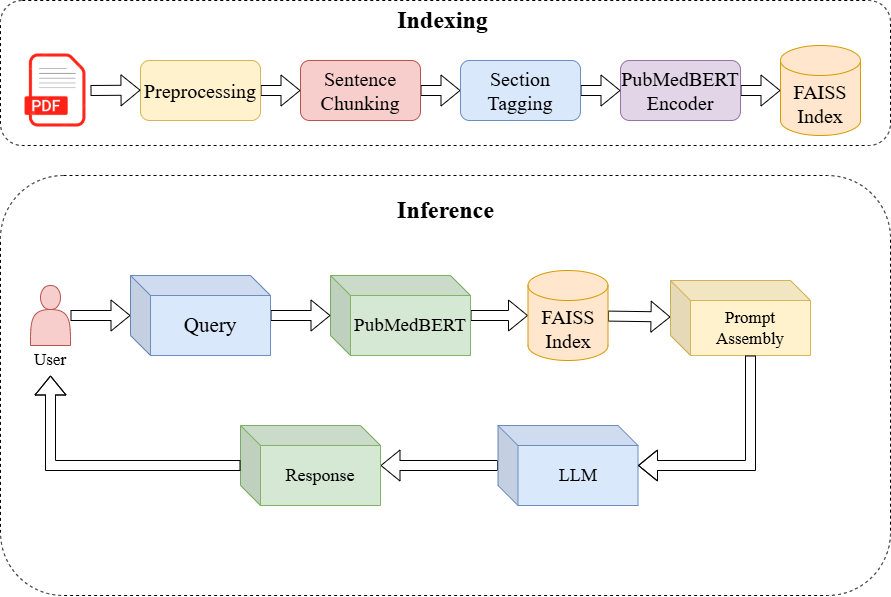

### Import Libraries

In [ ]:
!pip install -q transformers==4.51.0 sentence-transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.7 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from typing import List, Tuple
import re
from google.colab import files
import PyPDF2
import pickle

### Load Qwen3-8B (4-bit Quantized)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "Qwen/Qwen3-8B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,  # bfloat16 instead of float16
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

print("✓ Qwen3-8B loaded with 4-bit quantization!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00003-of-00005.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ Qwen3-8B loaded with 4-bit quantization!


This cell initializes and loads the Qwen3-8B large language model with 4-bit quantization to reduce memory usage, making it suitable for running in resource-constrained environments like Google Colab.

### Load Embedding Model (PubMedBERT)

In [ ]:
print("Loading embedding model...")
embedding_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')
print("✓ Embedding model loaded!")

Loading embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embedding model loaded!


This cell loads a domain-specific sentence embedding model used to convert text into dense vector representations for semantic search and retrieval tasks.

In [ ]:
# embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

In [ ]:
# embedding_model = SentenceTransformer('BAAI/bge-m3')

### Upload and Process Documents

In [ ]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """Extract text from PDF file."""
    with open(pdf_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

def clean_text(text: str) -> str:
    """Remove PDF artifacts, headers, footers, and fix formatting."""

    # ── Fix hyphenated line breaks first ──
    text = re.sub(r'-\n', '', text)

    # ── Remove known repeating headers/footers (flexible spacing) ──
    patterns_to_remove = [
        r'NEW\s+HAMPSHIRE\s+DEPARTMENT\s+OF\s+HEALTH\s+AND\s+HUMAN\s+SERVICES?',
        r'Division\s+of\s+Public\s+Health\s+Services',
        r'Bureau\s+of\s+Infectious\s+Disease\s+Control',
        r'Disease\s+Handbook\s+for\s+Childcare\s+Providers',
        r'REVISED?\s*[:\-–]?\s*\w*\s*\d*',           # catches REVISED with or without date
        r'Revised?\s*[:\-–]?\s*\w*\s*\d*',
        r'New\s+Hampshire\s+Department\s+of\s+Health\s+and\s+Human\s+Services',
        r'NH\s+Department\s+of\s+Health\s+and\s+Human\s+Services',
        r'The\s+Department\s+of\s+Health\s+and\s+Human\s+Services\W+Mission[^.]+\.',
        r'29\s+Hazen\s+Drive[^.]+(?:NH|603)[^.]*\.?',  # address block
        r'Concord,?\s*NH\s*\d{5}[-\s\d]*',             # city/zip
        r'Tel:\s*\(?\d{3}\)?[-\s]+\d{3}[-\s]+\d{4}',
        r'Fax:\s*\(?\d{3}\)?[-\s]+\d{3}[-\s]+\d{4}',
        r'\(603\)\s*\d+[-\s]*\d+',                     # any (603) phone number
        r'https?://\S+',
        r'TABLE\s+OF\s+CONTENTS[\s\S]{0,1000}(?=\n[A-Z])',
        r'[\w./]+\.nh\.gov\S*',                          # any nh.gov URL without https
        r'\b\w+\s*\(\s*\d+\s*page[s]?\s*\)',             # TOC entries like "Measles (2 pages)"
        r'\s+-\s+\d{4}',                                  # orphaned phone number endings like "- 4496"
    ]

    for pattern in patterns_to_remove:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # ── Remove standalone page numbers ──
    text = re.sub(r'(?<!\d)\b\d{1,3}\b(?!\d)(?=\s*\n)', '', text)

    # ── Remove list numbering at start of lines ──
    text = re.sub(r'^\s*\d+\.\s+', '', text, flags=re.MULTILINE)

    # ── Normalize whitespace ──
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r' +', ' ', text)

    # Fix spaced hyphens left by removals e.g. "disease -control" → "disease control"
    text = re.sub(r'\s+-\s+', ' ', text)
    text = re.sub(r'\s+-', ' ', text)

    # Fix broken spaced words from PDF (e.g. "Serv ices" → "Services")
    text = re.sub(r'(\w{3,})\s([a-z]{2,4})\b', lambda m: m.group(1) + m.group(2)
                  if m.group(1)[-1].isalpha() else m.group(0), text)

    # Remove any remaining orphaned short fragments from header removal
    text = re.sub(r'\b(Serv\w*|Bure\w*|Divis\w*)\b', '', text)

    text = re.sub(r'([a-z])(the|is|in|of|to|and|or|for|be|it|as|by|at|on|an|are|was|has|not|from|with|this|that|they|have|been|will|can|may|its|who|but|after|than|most|some|only|when|then|into|over|such|both|very|also|days|each)\b', r'\1 \2', text)
    return text.strip()

DISEASE_KEYWORDS = {
    'campylobacter': ['campylobacter', 'campylobacteriosis'],
    'e. coli': ['e. coli', 'escherichia coli', '0157:h7'],
    'salmonella': ['salmonella', 'salmonellosis'],
    'shigella': ['shigella', 'shigellosis'],
    'strep': ['strep throat', 'streptococcal', 'scarlet fever'],
    'chickenpox': ['chickenpox', 'chicken pox', 'varicella', 'shingles'],
    'influenza': ['influenza', 'flu', 'seasonal flu'],
    'hepatitis a': ['hepatitis a', 'hep a'],
    'hepatitis b': ['hepatitis b', 'hbv', 'hepatitis b virus'],
    'measles': ['measles', 'rubeola'],
    'norovirus': ['norovirus', 'stomach flu'],
    'rotavirus': ['rotavirus'],
    'giardia': ['giardia', 'giardiasis'],
    'pinworm': ['pinworm', 'pinworms', 'enterobius'],
    'scabies': ['scabies', 'sarcoptes scabiei'],
    'head lice': ['head lice', 'pediculosis', 'lice', 'nits'],
    'ringworm': ['ringworm', 'tinea'],
    'conjunctivitis': ['conjunctivitis', 'pink eye'],
    'impetigo': ['impetigo', 'staphylococcal bacteria', 'streptococcal bacteria'],
    'diarrhea': ['diarrhea', 'diarrhoea', 'gastroenteritis'],
    'hand foot mouth': ['hand foot', 'hand-foot-mouth', 'coxsackie'],
    'rsv': ['rsv', 'respiratory syncytial virus'],
    'mrsa': ['mrsa', 'methicillin-resistant', 'staphylococcus aureus'],
    'hiv': ['hiv', 'aids', 'human immunodeficiency'],
    'rabies': ['rabies', 'rabid'],
    'lyme': ['lyme disease', 'borrelia', 'tick-borne'],
    'pertussis': ['pertussis', 'whooping cough'],
    'mumps': ['mumps', 'parotitis'],
    'rubella': ['rubella', 'german measles'],
    'meningococcal': ['meningococcal', 'meningitis', 'meningococcus'],
    'oral herpes': ['oral herpes', 'cold sores', 'herpes simplex'],
    'eee': ['eastern equine encephalitis', 'eee', 'encephalitis'],
    'polio': ['polio', 'poliomyelitis'],
    'roseola': ['roseola', 'sixth disease', 'exanthem subitum'],
    'swimmers itch': ['swimmer', 'cercarial dermatitis'],
    'tetanus': ['tetanus', 'lockjaw'],
    'tuberculosis': ['tuberculosis', 'tb', 'mycobacterium'],
    'west nile': ['west nile', 'wnv'],
    'fifth disease': ['fifth disease', 'parvovirus', 'slapped cheek'],
    'haemophilus': ['haemophilus', 'hib', 'haemophilus influenza type b'],
}

def detect_section(sentence: str):
    sentence_lower = sentence.lower().strip()
    for disease, keywords in DISEASE_KEYWORDS.items():
        for keyword in keywords:
            if keyword in sentence_lower:
                return disease.title()
    return None

def chunk_text(text: str, chunk_size: int = 5, overlap: int = 1) -> List[str]:
    """Split text into sentence-aware chunks with section labels."""
    sentences = sent_tokenize(text)
    chunks = []
    current_section = "General"

    i = 0
    while i < len(sentences):
        detected = detect_section(sentences[i])
        if detected:
            current_section = detected

        chunk_sentences = sentences[i:i + chunk_size]
        chunk = ' '.join(chunk_sentences)
        chunks.append(f"Section: {current_section}\n\n{chunk}")
        i += (chunk_size - overlap)

    return chunks

# Upload PDF
print("Upload your medical document (PDF):")
uploaded = files.upload()

all_chunks = []
for filename in uploaded.keys():
    print(f"\nProcessing: {filename}")
    raw_text = extract_text_from_pdf(filename)
    clean = clean_text(raw_text)
    chunks = chunk_text(clean)
    all_chunks.extend(chunks)
    print(f"  - Extracted {len(chunks)} chunks")

print(f"\n✓ Total chunks: {len(all_chunks)}")

Upload your medical document (PDF):


Saving disease-handbook-complete.pdf to disease-handbook-complete.pdf

Processing: disease-handbook-complete.pdf
  - Extracted 484 chunks

✓ Total chunks: 484


This cell defines the full document processing pipeline from raw PDF upload to clean, labeled text chunks ready for embedding and retrieval.

* extract_text_from_pdf(pdf_path)

  Reads a PDF file using PyPDF2 and extracts raw text from every page, concatenating them into a single string.

 * clean_text(text)
  Sanitizes raw PDF text by removing noise and normalizing formatting. Specifically it:

    Fixes hyphenated line breaks (e.g. treat-\nment → treatment)
    Strips recurring headers/footers specific to NH DHHS documents (agency names, addresses, phone numbers, URLs, TOC entries)
    Removes standalone page numbers and list numbering
    Normalizes whitespace and broken words caused by PDF rendering artifacts


`DISEASE_KEYWORDS`

* A lookup dictionary mapping disease names to their common aliases and synonyms (e.g. "measles" → ["measles", "rubeola"]). Used to label chunks with the relevant disease section during chunking.

* detect_section(sentence)
Scans a sentence against DISEASE_KEYWORDS and returns the matched disease name (title-cased), or "General" if no match is found. Used to track the active topic as the document is read sentence by sentence.

* chunk_text(text, chunk_size=5, overlap=1)
Splits cleaned text into overlapping sentence-level chunks, each prefixed with its detected disease section label. The overlap ensures context isn't lost at chunk boundaries.
ParameterDefaultPurposechunk_size5Sentences per chunkoverlap1Shared sentences between adjacent chunks

* Execution Block
Prompts the user to upload a PDF, runs it through the full pipeline (extract → clean → chunk), and accumulates all chunks into all_chunks for downstream embedding.

### Create FAISS Index

In [ ]:
# Generate embeddings
embeddings = embedding_model.encode(all_chunks, show_progress_bar=True)

# Create FAISS index
dimension = embeddings.shape[1]
faiss.normalize_L2(embeddings.astype('float32'))
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product = cosine on normalized vectors
index.add(embeddings.astype('float32'))

print(f"✓ FAISS index created with {index.ntotal} vectors")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ FAISS index created with 484 vectors


This cell converts all text chunks into dense vector embeddings and builds a FAISS vector index for fast semantic similarity search.

### RAG Generation Function

In [ ]:
def retrieve_context(query: str, top_k: int = 5) -> List[str]:
    query_embedding = embedding_model.encode([query]).astype('float32')
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, top_k)
    return [all_chunks[i] for i in indices[0]]

def generate_answer(question: str, context: List[str], max_new_tokens: int = 300) -> str:
    """Generate answer using Qwen3-8B with retrieved context."""
    context_text = "\n\n".join(context)

    messages = [
        {"role": "system", "content":
            """You are a medical assistant for childcare providers using the NH Disease Handbook.
Answer the question using ONLY the information in the Medical Context below.
Be direct, specific, and concise. Do not add any outside knowledge.
If the question is not related to childcare diseases, symptoms, treatments, prevention, or exclusion policies, respond with exactly:
"I'm sorry, I don't have information about that in the childcare disease handbook. Please consult a healthcare provider for further guidance."
If the answer is not found in the Medical Context, respond with exactly:
"I'm sorry, I don't have information about that in the childcare disease handbook. Please consult a healthcare provider for further guidance." """},
        {"role": "user", "content": f"Medical Context:\n{context_text}\n\nQuestion: {question}"}
    ]

    # enable_thinking=False disables <think> blocks
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[1]
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Remove duplicate sentences and cap at 6
    sentences = sent_tokenize(answer)
    seen = []
    for sent in sentences:
        if not any(sent.strip() == s.strip() for s in seen):
            seen.append(sent)
    return ' '.join(seen[:6])

def rag_query(question: str, top_k: int = 7) -> dict:
    """Complete RAG pipeline: retrieve + generate."""
    context = retrieve_context(question, top_k=top_k)
    answer = generate_answer(question, context)
    return {
        "question": question,
        "answer": answer,
        "context": context
    }

print("✓ RAG functions ready!")

✓ RAG functions ready!


This cell defines the core Retrieval-Augmented Generation (RAG) pipeline, combining semantic search with the Qwen3-8B model to answer childcare disease-related questions grounded strictly in the uploaded NH Disease Handbook.

---

## Section 5. System Evaluation (Unseen Queries)

This section evaluates the RAG pipeline on a held-out set of 43 questions that were **not used during development**. The evaluation covers five difficulty tiers: easy, medium, hard, and natural language queries.

### 5.1 Evaluation Setup

Evaluation was performed using **manual benchmark questions** designed to simulate realistic childcare provider queries. The 43 questions span:

| Tier | Count | Description |
|---|---|---|
| Easy | 11 | Single-fact, single-disease questions |
| Medium | 12 | Multi-step or procedural questions |
| Hard | 10 | Cross-disease comparisons, policy questions |
| Natural | 10 | Informal, colloquial queries from parents/caregivers |

Each question is annotated with ground-truth keywords (used to label retrieved chunks as relevant) and an expected answer.



In [ ]:
eval_dataset = [
  {
    "question_id": "q01",
    "question": "What is the incubation period for chickenpox?",
    "difficulty": "easy",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "Symptoms usually appear 14 to 16 days after exposure, but can range from 10 to 21 days.",
    "relevant_keywords": ["varicella", "incubation period", "exposure", "symptoms"],
    "expected_chunk_topics": ["Chickenpox fact sheet: incubation period and symptoms"]
  },
  {
    "question_id": "q02",
    "question": "What are the main symptoms of Fifth Disease?",
    "difficulty": "easy",
    "disease_topic": "Fifth Disease",
    "ground_truth_answer": "The classic symptom is a facial rash that looks like slapped cheeks, followed by a lacy rash on the trunk and limbs. Some children may have mild fever, sore throat, or joint pain before the rash appears.",
    "relevant_keywords": ["parvovirus B19", "slapped cheek", "rash", "fever"],
    "expected_chunk_topics": ["Fifth Disease fact sheet: symptoms and description"]
  },
  {
    "question_id": "q03",
    "question": "How is impetigo typically treated?",
    "difficulty": "easy",
    "disease_topic": "Impetigo",
    "ground_truth_answer": "Impetigo is treated with antibiotics, either topical creams or oral medication, and keeping the affected area clean and covered. Treatment usually lasts several days.",
    "relevant_keywords": ["staphylococcus", "streptococcus", "antibiotics", "skin infection"],
    "expected_chunk_topics": ["Impetigo fact sheet: treatment and management"]
  },
  {
    "question_id": "q04",
    "question": "How long is a person with measles contagious?",
    "difficulty": "easy",
    "disease_topic": "Measles",
    "ground_truth_answer": "A person with measles can spread the virus from 4 days before the rash appears until 4 days after the rash starts.",
    "relevant_keywords": ["rubeola", "contagious period", "rash", "transmission"],
    "expected_chunk_topics": ["Measles fact sheet: contagious period and exclusion"]
  },
  {
    "question_id": "q05",
    "question": "How long does a child with hepatitis A need to stay home from childcare?",
    "difficulty": "easy",
    "disease_topic": "Hepatitis A",
    "ground_truth_answer": "A child with hepatitis A should be excluded for one week after the onset of symptoms, such as jaundice, or until a healthcare provider determines they are no longer infectious.",
    "relevant_keywords": ["HAV", "jaundice", "exclusion", "infectious period"],
    "expected_chunk_topics": ["Hepatitis A fact sheet: exclusion and prevention"]
  },
  {
    "question_id": "q06",
    "question": "What is the main way to prevent the spread of head lice?",
    "difficulty": "easy",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Prevent head lice by avoiding sharing personal items like combs, brushes, hats, and bedding. If an infestation occurs, treat the person and wash clothing and bedding in hot water.",
    "relevant_keywords": ["head lice", "nits", "personal items", "hygiene"],
    "expected_chunk_topics": ["Pediculosis fact sheet: prevention and treatment"]
  },
  {
    "question_id": "q07",
    "question": "What are the common symptoms of pinworms?",
    "difficulty": "easy",
    "disease_topic": "Pinworms",
    "ground_truth_answer": "Symptoms include intense anal itching, especially at night, irritability, and disturbed sleep. Many infected children may have no symptoms at all.",
    "relevant_keywords": ["enterobius", "anal itching", "nocturnal", "irritability"],
    "expected_chunk_topics": ["Pinworms fact sheet: symptoms and transmission"]
  },
  {
    "question_id": "q08",
    "question": "How is ringworm of the skin treated?",
    "difficulty": "easy",
    "disease_topic": "Ringworm",
    "ground_truth_answer": "Ringworm on the skin is usually treated with over-the-counter antifungal creams or lotions. For scalp ringworm, a prescription oral medication is needed.",
    "relevant_keywords": ["tinea", "antifungal", "skin infection", "scalp"],
    "expected_chunk_topics": ["Ringworm fact sheet: treatment and prevention"]
  },
  {
    "question_id": "q09",
    "question": "What is the exclusion period for a child with strep throat?",
    "difficulty": "easy",
    "disease_topic": "Strep Throat",
    "ground_truth_answer": "A child with strep throat should be excluded until they have been on antibiotics for at least 24 hours and no longer have a fever.",
    "relevant_keywords": ["group A streptococcus", "antibiotics", "fever", "exclusion"],
    "expected_chunk_topics": ["Strep Throat fact sheet: treatment and exclusion"]
  },
  {
    "question_id": "q10",
    "question": "How is rabies transmitted to humans?",
    "difficulty": "easy",
    "disease_topic": "Rabies",
    "ground_truth_answer": "Rabies is transmitted through a bite from an infected animal, or when saliva or brain tissue from a rabid animal enters a persons broken skin or mucous membranes.",
    "relevant_keywords": ["lyssavirus", "bite", "saliva", "animal exposure"],
    "expected_chunk_topics": ["Rabies fact sheet: transmission and prevention"]
  },
  {
    "question_id": "q51",
    "question": "What are the symptoms and exclusion requirements for Hand-Foot-Mouth Disease?",
    "difficulty": "easy",
    "disease_topic": "Hand-Foot-Mouth Disease",
    "ground_truth_answer": "Hand-foot-mouth disease causes fever, sore throat, and a blister-like rash on the hands, feet, and inside the mouth. Children may be excluded while they have fever or open sores, but can usually return once they feel well enough to participate in activities.",
    "relevant_keywords": ["coxsackievirus", "blisters", "mouth sores", "rash", "exclusion"],
    "expected_chunk_topics": ["Hand-Foot-Mouth Disease fact sheet: symptoms and exclusion"]
  },
  {
    "question_id": "q11",
    "question": "Compare how Hepatitis A and Hepatitis B are spread in a childcare setting.",
    "difficulty": "medium",
    "disease_topic": "Hepatitis A and B",
    "ground_truth_answer": "Hepatitis A is spread through the fecal-oral route, often via contaminated food, water, or surfaces touched by an infected person. Hepatitis B is spread through blood, semen, or saliva, typically via open wounds, bites, or contact with infected body fluids. Hepatitis A is more easily spread in diapered children due to poor hygiene.",
    "relevant_keywords": ["HAV", "HBV", "fecal-oral", "bloodborne", "transmission"],
    "expected_chunk_topics": ["Hepatitis A fact sheet: spread", "Hepatitis B fact sheet: spread"]
  },
  {
    "question_id": "q12",
    "question": "What steps should be taken if a child is diagnosed with head lice?",
    "difficulty": "medium",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Notify the parents, treat the child with an over-the-counter or prescription lice-killing shampoo, remove nits with a fine-tooth comb, wash all bedding and clothing in hot water, vacuum floors and furniture, and avoid sharing personal items. The child can return to childcare after the first treatment, even if nits remain.",
    "relevant_keywords": ["head lice", "treatment", "nits", "cleaning", "exclusion"],
    "expected_chunk_topics": ["Pediculosis fact sheet: treatment and environmental measures"]
  },
  {
    "question_id": "q13",
    "question": "How does the exclusion policy differ for a child with chickenpox versus a child with Fifth disease?",
    "difficulty": "medium",
    "disease_topic": "Chickenpox and Fifth Disease",
    "ground_truth_answer": "A child with chickenpox must be excluded until all blisters have crusted over, usually about 5-7 days after rash onset. A child with Fifth disease does not need to be excluded because they are no longer contagious once the rash appears; they can attend childcare if they feel well.",
    "relevant_keywords": ["varicella", "parvovirus B19", "exclusion", "contagious period"],
    "expected_chunk_topics": ["Chickenpox fact sheet: exclusion", "Fifth Disease fact sheet: exclusion"]
  },
  {
    "question_id": "q14",
    "question": "What are the recommended immunizations for childcare workers according to the handbook?",
    "difficulty": "medium",
    "disease_topic": "Immunizations",
    "ground_truth_answer": "Childcare workers are strongly recommended to have proof of immunity or vaccination for Tdap, measles, mumps, rubella, varicella, hepatitis B, and annual influenza. Evidence can include vaccination records or lab tests.",
    "relevant_keywords": ["vaccines", "Tdap", "MMR", "varicella", "hepatitis B", "influenza"],
    "expected_chunk_topics": ["Adult Vaccination Recommendations section", "Immunization Requirements"]
  },
  {
    "question_id": "q15",
    "question": "Describe the proper procedure for cleaning up a blood spill in a childcare facility.",
    "difficulty": "medium",
    "disease_topic": "Bloodborne pathogens",
    "ground_truth_answer": "Wear disposable gloves, clean the spill with soap and water to remove visible blood, then disinfect the area with a bleach solution and let it air dry. Dispose of gloves and cleaning materials properly, then wash hands thoroughly.",
    "relevant_keywords": ["blood", "disinfection", "bleach", "gloves", "standard precautions"],
    "expected_chunk_topics": ["Hepatitis B fact sheet: prevention", "General disinfection guidelines"]
  },
  {
    "question_id": "q16",
    "question": "Which diseases require immediate reporting to the health department?",
    "difficulty": "medium",
    "disease_topic": "Reportable diseases",
    "ground_truth_answer": "Many diseases are reportable in New Hampshire, including measles, mumps, rubella, pertussis, hepatitis A, meningococcal disease, tuberculosis, and rabies. The handbook lists reportable diseases on each fact sheet and in the introduction.",
    "relevant_keywords": ["reportable", "notifiable", "health department", "surveillance"],
    "expected_chunk_topics": ["Each disease fact sheet reportable section", "Introduction"]
  },
  {
    "question_id": "q17",
    "question": "How can you differentiate between viral and bacterial conjunctivitis?",
    "difficulty": "medium",
    "disease_topic": "Conjunctivitis",
    "ground_truth_answer": "Viral conjunctivitis typically has watery discharge and may accompany cold symptoms; bacterial conjunctivitis often produces thick yellow or white pus, with eyelids stuck together after sleep. Bacterial conjunctivitis may require antibiotics, while viral usually resolves on its own.",
    "relevant_keywords": ["pink eye", "purulent", "discharge", "antibiotics"],
    "expected_chunk_topics": ["Conjunctivitis fact sheet: symptoms and types"]
  },
  {
    "question_id": "q18",
    "question": "What are the key differences between the common cold and influenza?",
    "difficulty": "medium",
    "disease_topic": "Common Cold and Influenza",
    "ground_truth_answer": "Influenza usually has sudden onset of high fever, body aches, fatigue, and headache, while colds are milder with runny nose, sneezing, and sore throat. Both are viral, but influenza can lead to serious complications. Annual flu vaccine is recommended for prevention.",
    "relevant_keywords": ["flu", "respiratory", "fever", "vaccine"],
    "expected_chunk_topics": ["Common Cold and Influenza fact sheet: symptoms and prevention"]
  },
  {
    "question_id": "q19",
    "question": "What precautions should be taken when changing a diaper to prevent the spread of infections?",
    "difficulty": "medium",
    "disease_topic": "Diapering",
    "ground_truth_answer": "Gather supplies first, place child on a clean surface, clean the child with wipes, fold soiled diaper inward, dispose properly, wash the childs hands, sanitize the changing surface with bleach solution, and wash your own hands thoroughly.",
    "relevant_keywords": ["diaper", "handwashing", "sanitize", "fecal-oral", "infection control"],
    "expected_chunk_topics": ["Diapering Recommendations section"]
  },
  {
    "question_id": "q20",
    "question": "What are the symptoms of Lyme disease and how is it treated?",
    "difficulty": "medium",
    "disease_topic": "Lyme Disease",
    "ground_truth_answer": "Early symptoms include a characteristic expanding circular rash called erythema migrans, along with fever, headache, fatigue, and muscle aches. Later complications can affect joints, heart, and nervous system. Treatment involves antibiotics and early treatment improves outcomes.",
    "relevant_keywords": ["Borrelia burgdorferi", "tick", "rash", "antibiotics"],
    "expected_chunk_topics": ["Lyme Disease fact sheet: symptoms and treatment"]
  },
  {
    "question_id": "q52",
    "question": "How is MRSA spread in a childcare setting and how can it be prevented?",
    "difficulty": "medium",
    "disease_topic": "MRSA",
    "ground_truth_answer": "MRSA spreads through direct skin-to-skin contact or by touching contaminated surfaces and objects. Prevention includes frequent handwashing, keeping wounds covered, avoiding sharing personal items like towels, and regularly disinfecting surfaces. Children with active draining wounds that cannot be covered should be excluded.",
    "relevant_keywords": ["MRSA", "methicillin-resistant", "skin contact", "wound", "disinfection"],
    "expected_chunk_topics": ["MRSA fact sheet: transmission and prevention"]
  },
  {
    "question_id": "q53",
    "question": "What are the symptoms of RSV and which children are most at risk for serious illness?",
    "difficulty": "medium",
    "disease_topic": "RSV",
    "ground_truth_answer": "RSV causes cold-like symptoms including runny nose, cough, and fever. In most children it is mild, but infants under 6 months, premature babies, and children with heart or lung conditions are at higher risk for severe illness including bronchiolitis and pneumonia.",
    "relevant_keywords": ["RSV", "respiratory syncytial virus", "bronchiolitis", "infants", "high risk"],
    "expected_chunk_topics": ["RSV fact sheet: symptoms and risk factors"]
  },
  {
    "question_id": "q21",
    "question": "Which diseases in the handbook require exclusion of a child from childcare until they are no longer infectious, and what are the specific exclusion periods?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Chickenpox: until blisters crust. Measles: at least 4 days after rash. Rubella: 7 days after rash. Mumps: 5 days after swelling. Pertussis: after 5 days of antibiotics or until no longer coughing. Hepatitis A: 1 week after onset. Impetigo: 24 hours after starting treatment. Strep throat: 24 hours after antibiotics and fever-free. Diarrheal diseases: until 48 hours symptom-free. Some require negative stool cultures such as E. coli and Shigella.",
    "relevant_keywords": ["exclusion", "contagious period", "return to childcare", "isolation"],
    "expected_chunk_topics": ["Individual disease fact sheets exclusion sections", "When A Child Should Be Excluded Or Dismissed"]
  },
  {
    "question_id": "q22",
    "question": "List all diseases that are transmitted via the fecal-oral route and explain why diapering practices are critical for preventing them.",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Diseases spread by fecal-oral route include Campylobacter, E. coli O157:H7, Giardia, Hepatitis A, Norovirus, Rotavirus, Salmonella, and Shigella. Diapering practices are critical because these pathogens are present in stool and improper handling can contaminate hands, surfaces, and toys, leading to ingestion by other children.",
    "relevant_keywords": ["fecal-oral", "diarrhea", "handwashing", "diapering", "transmission"],
    "expected_chunk_topics": ["Diapering Recommendations", "Individual disease fact sheets transmission sections"]
  },
  {
    "question_id": "q23",
    "question": "What are the immunization requirements for children attending childcare in New Hampshire?",
    "difficulty": "hard",
    "disease_topic": "Immunizations",
    "ground_truth_answer": "Children must be age-appropriately vaccinated against diphtheria, tetanus, pertussis, polio, Haemophilus influenzae type b, measles, mumps, rubella, varicella, and hepatitis B. Additional vaccines like hepatitis A, influenza, pneumococcal, and rotavirus are recommended but not required.",
    "relevant_keywords": ["vaccine schedule", "DTaP", "MMR", "Hib", "IPV", "varicella", "hepatitis B"],
    "expected_chunk_topics": ["Immunization Requirements section", "Vaccine-Preventable Diseases"]
  },
  {
    "question_id": "q24",
    "question": "For which diseases is it recommended that exposed pregnant women consult their healthcare provider?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Pregnant women should consult their provider if exposed to Fifth disease, chickenpox, or rubella as these can affect the fetus. The handbook specifically highlights these three as concerns during pregnancy.",
    "relevant_keywords": ["pregnancy", "fetal risk", "parvovirus B19", "rubella", "varicella"],
    "expected_chunk_topics": ["Fifth Disease fact sheet", "Chickenpox fact sheet", "Rubella fact sheet"]
  },
  {
    "question_id": "q25",
    "question": "What are the criteria for excluding a child with diarrhea from childcare, and how does it vary by specific causative agent?",
    "difficulty": "hard",
    "disease_topic": "Diarrheal diseases",
    "ground_truth_answer": "General rule: exclude until diarrhea has stopped for 48 hours. For E. coli O157:H7 and Shigella, two negative stool cultures taken 24 hours apart are required. Salmonella requires 48 hours symptom-free. Hepatitis A requires one week after symptom onset.",
    "relevant_keywords": ["diarrhea", "exclusion", "stool culture", "E. coli", "Shigella", "Salmonella"],
    "expected_chunk_topics": ["Diarrhea fact sheet", "E. coli fact sheet", "Shigellosis fact sheet", "Salmonellosis fact sheet"]
  },
  {
    "question_id": "q26",
    "question": "Compare the transmission routes and exclusion periods for measles and chickenpox.",
    "difficulty": "hard",
    "disease_topic": "Measles and Chickenpox",
    "ground_truth_answer": "Both are spread by airborne droplets and direct contact. Measles is contagious from 4 days before to 4 days after rash; chickenpox from 1-2 days before rash until all blisters crust over. Exclusion for measles is 4 days after rash; for chickenpox it is until all blisters have crusted.",
    "relevant_keywords": ["rubeola", "varicella", "airborne", "exclusion", "contagious"],
    "expected_chunk_topics": ["Measles fact sheet", "Chickenpox fact sheet"]
  },
  {
    "question_id": "q27",
    "question": "What diseases can be prevented by vaccination according to the handbook, and which vaccines are required for childcare?",
    "difficulty": "hard",
    "disease_topic": "Vaccine-preventable diseases",
    "ground_truth_answer": "Vaccine-preventable diseases include diphtheria, tetanus, pertussis, polio, measles, mumps, rubella, varicella, Hib, hepatitis B, hepatitis A, pneumococcal disease, rotavirus, and influenza. Required for childcare are DTaP, IPV, Hib, MMR, varicella, and hepatitis B.",
    "relevant_keywords": ["vaccines", "immunization", "required", "schedule"],
    "expected_chunk_topics": ["Immunization Requirements section", "Vaccine-Preventable Diseases section"]
  },
  {
    "question_id": "q28",
    "question": "How should a childcare facility handle an outbreak of norovirus?",
    "difficulty": "hard",
    "disease_topic": "Norovirus",
    "ground_truth_answer": "Exclude symptomatic individuals until 48 hours after symptoms resolve, enhance handwashing, clean and disinfect surfaces with bleach solution, dispose of vomit and diarrhea safely, and report the outbreak to the health department. Consider restricting food handling by ill staff.",
    "relevant_keywords": ["norovirus", "outbreak", "disinfection", "exclusion", "reporting"],
    "expected_chunk_topics": ["Norovirus fact sheet: prevention and exclusion", "Diarrhea section"]
  },
  {
    "question_id": "q29",
    "question": "Which diseases in the handbook spread through both direct contact and airborne transmission?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Diseases that spread through both direct contact and airborne or respiratory droplet transmission include chickenpox, measles, mumps, rubella, influenza, and pertussis. These require extra precaution in childcare settings because they can spread even without physical contact.",
    "relevant_keywords": ["airborne", "droplet", "direct contact", "transmission", "respiratory"],
    "expected_chunk_topics": ["Chickenpox fact sheet", "Measles fact sheet", "Influenza fact sheet", "Pertussis fact sheet"]
  },
  {
    "question_id": "q30",
    "question": "Which diseases require two negative stool cultures before returning to childcare?",
    "difficulty": "hard",
    "disease_topic": "E. coli and Shigella",
    "ground_truth_answer": "E. coli O157:H7 and Shigellosis require two consecutive negative stool cultures taken at least 24 hours apart before a person can return to childcare. For Salmonella, exclusion is based on 48 hours symptom-free, not two negative cultures.",
    "relevant_keywords": ["stool culture", "E. coli", "Shigella", "clearance", "exclusion"],
    "expected_chunk_topics": ["E. coli O157:H7 fact sheet", "Shigellosis fact sheet"]
  },
  {
    "question_id": "q41",
    "question": "my kid has a rash and a fever, what could it be?",
    "difficulty": "natural",
    "disease_topic": "Multiple",
    "ground_truth_answer": "Many childhood illnesses cause rash and fever, including measles, chickenpox, fifth disease, scarlet fever, or hand-foot-mouth disease. It is important to see a healthcare provider for a proper diagnosis, as some of these require exclusion from childcare.",
    "relevant_keywords": ["rash", "fever", "child", "diagnosis"],
    "expected_chunk_topics": ["Rashes section", "Various disease fact sheets"]
  },
  {
    "question_id": "q42",
    "question": "how long do i keep my child home with pink eye?",
    "difficulty": "natural",
    "disease_topic": "Conjunctivitis",
    "ground_truth_answer": "For pink eye with pus, keep your child home until they have been seen by a doctor and have started antibiotic treatment for at least 24 hours. For mild watery pink eye without pus, they may not need to stay home if they feel well.",
    "relevant_keywords": ["pink eye", "conjunctivitis", "exclusion", "childcare"],
    "expected_chunk_topics": ["Conjunctivitis fact sheet: exclusion"]
  },
  {
    "question_id": "q43",
    "question": "my daughter has spots all over her body and she's itchy, is it chickenpox?",
    "difficulty": "natural",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "Itchy spots that turn into blisters and then crust over are classic for chickenpox. However, other conditions like hand-foot-mouth disease or allergic reactions can also cause spots. A healthcare provider should confirm the diagnosis.",
    "relevant_keywords": ["spots", "itchy", "chickenpox", "blisters"],
    "expected_chunk_topics": ["Chickenpox fact sheet: symptoms"]
  },
  {
    "question_id": "q44",
    "question": "whats that disease where kids get red cheeks?",
    "difficulty": "natural",
    "disease_topic": "Fifth Disease",
    "ground_truth_answer": "That sounds like Fifth Disease, caused by parvovirus B19. It causes a bright red rash on the cheeks resembling slapped cheeks, followed by a lacy rash on the body. It is usually mild and children are not contagious once the rash appears.",
    "relevant_keywords": ["red cheeks", "slapped cheek", "fifth disease"],
    "expected_chunk_topics": ["Fifth Disease fact sheet"]
  },
  {
    "question_id": "q45",
    "question": "can my kid go to daycare if he has a cold but no fever?",
    "difficulty": "natural",
    "disease_topic": "Common Cold",
    "ground_truth_answer": "If your child has only mild cold symptoms like runny nose and is able to participate comfortably in activities, they can usually attend. However, if they have uncontrolled coughing or are lethargic they should stay home. Check your daycare policy.",
    "relevant_keywords": ["cold", "daycare", "attendance", "fever"],
    "expected_chunk_topics": ["When A Child Should Be Excluded Or Dismissed", "Common Cold fact sheet"]
  },
  {
    "question_id": "q46",
    "question": "i think my son has pinworms, what do i do?",
    "difficulty": "natural",
    "disease_topic": "Pinworms",
    "ground_truth_answer": "Take your son to a healthcare provider for diagnosis and treatment. At home, wash all bedding and clothing in hot water, vacuum floors, and encourage frequent handwashing. Inform the daycare so they can watch for other cases.",
    "relevant_keywords": ["pinworms", "treatment", "hygiene", "childcare"],
    "expected_chunk_topics": ["Pinworms fact sheet: treatment and prevention"]
  },
  {
    "question_id": "q47",
    "question": "how do you get rid of head lice fast?",
    "difficulty": "natural",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Use an over-the-counter lice treatment according to package directions, then comb out nits with a fine-tooth comb. Wash all bedding, hats, and clothing in hot water, and vacuum carpets and furniture. Repeat treatment in 7-10 days if needed.",
    "relevant_keywords": ["head lice", "treatment", "nits", "fast"],
    "expected_chunk_topics": ["Pediculosis fact sheet: treatment"]
  },
  {
    "question_id": "q48",
    "question": "my baby has diarrhea, should I keep him home?",
    "difficulty": "natural",
    "disease_topic": "Diarrhea",
    "ground_truth_answer": "Yes, if the diarrhea is uncontrolled or more than 2 stools above normal, keep your baby home until it stops. Diarrhea can spread easily in childcare. If it persists or is accompanied by fever, blood, or signs of dehydration, see a doctor.",
    "relevant_keywords": ["diarrhea", "baby", "exclusion", "childcare"],
    "expected_chunk_topics": ["Diarrhea fact sheet", "When A Child Should Be Excluded Or Dismissed"]
  },
  {
    "question_id": "q49",
    "question": "whats the difference between strep throat and a regular sore throat?",
    "difficulty": "natural",
    "disease_topic": "Strep Throat",
    "ground_truth_answer": "Strep throat is caused by bacteria and often includes fever, swollen lymph nodes, and pain when swallowing but usually no cough or runny nose. A regular sore throat is usually viral and may come with cold symptoms. A rapid test or throat culture can confirm strep.",
    "relevant_keywords": ["strep throat", "sore throat", "difference", "symptoms"],
    "expected_chunk_topics": ["Strep Throat fact sheet: symptoms and diagnosis"]
  },
  {
    "question_id": "q50",
    "question": "can my child go to school with impetigo?",
    "difficulty": "natural",
    "disease_topic": "Impetigo",
    "ground_truth_answer": "No, a child with untreated impetigo should stay home until they have been on antibiotics for at least 24 hours. After that they can return, but keep the sores covered with a bandage to prevent spreading.",
    "relevant_keywords": ["impetigo", "school", "exclusion", "treatment"],
    "expected_chunk_topics": ["Impetigo fact sheet: exclusion"]
  }
]

print(f"✓ Evaluation dataset loaded: {len(eval_dataset)} questions")

from collections import Counter
difficulty_counts = Counter(d['difficulty'] for d in eval_dataset)
print(f"  Easy:         {difficulty_counts['easy']}")
print(f"  Medium:       {difficulty_counts['medium']}")
print(f"  Hard:         {difficulty_counts['hard']}")
print(f"  Natural:      {difficulty_counts['natural']}")
print(f"  Unique diseases covered: {len(set(d['disease_topic'] for d in eval_dataset))}")

✓ Evaluation dataset loaded: 43 questions
  Easy:         11
  Medium:       12
  Hard:         10
  Natural:      10
  Unique diseases covered: 31


### Retrieval Metrics Implementation

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def is_chunk_relevant(chunk: str, relevant_chunks: list, threshold: float = 0.70) -> bool:
    """
    Check if a retrieved chunk matches any ground-truth relevant chunk.
    Uses fuzzy similarity rather than exact match to handle minor chunking differences.
    """
    chunk_emb = embedding_model.encode([chunk])
    gt_embs = embedding_model.encode(relevant_chunks)
    sims = cosine_similarity(chunk_emb, gt_embs)[0]
    return sims.max() >= threshold

def recall_at_k(retrieved_chunks: list, relevant_chunks: list) -> float:
    """
    Recall@K = ground-truth chunks covered / total ground-truth chunks.
    Each ground-truth chunk can only be matched once.
    """
    matched_gt = set()

    for ret_chunk in retrieved_chunks:
        ret_emb = embedding_model.encode([ret_chunk])
        gt_embs = embedding_model.encode(relevant_chunks)
        sims = cosine_similarity(ret_emb, gt_embs)[0]

        best_gt_idx = sims.argmax()
        if sims[best_gt_idx] >= 0.70:
            matched_gt.add(best_gt_idx)  # set prevents double-counting

    return len(matched_gt) / len(relevant_chunks)

def precision_at_k(retrieved_chunks: list, relevant_chunks: list) -> float:
    """
    Precision@K = relevant chunks retrieved / K.
    """
    retrieved_relevant = sum(1 for c in retrieved_chunks if is_chunk_relevant(c, relevant_chunks))
    return retrieved_relevant / len(retrieved_chunks) if retrieved_chunks else 0.0

def context_relevancy(query: str, retrieved_chunks: list) -> float:
    """
    Context Relevancy = average cosine similarity between the query embedding
    and each retrieved chunk embedding.
    Measures semantic alignment of retrieved context to the query.
    """
    query_emb = embedding_model.encode([query])
    chunk_embs = embedding_model.encode(retrieved_chunks)
    sims = cosine_similarity(query_emb, chunk_embs)[0]
    return float(np.mean(sims))

print("✓ Retrieval metric functions defined: recall_at_k, precision_at_k, context_relevancy")


✓ Retrieval metric functions defined: recall_at_k, precision_at_k, context_relevancy


This cell defines four evaluation functions used to measure the quality of the RAG pipeline's retrieval step specifically, how well the FAISS vector search surfaces relevant chunks for a given query.

### Run Full Evaluation

This cell runs the retrieval evaluation pipeline across the entire `eval_dataset`, computing per-sample retrieval metrics and logging results for downstream analysis.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

TOP_K = 7

results = []

def chunk_has_keyword(chunk, kws):
    chunk_lower = chunk.lower()
    return any(kw.lower() in chunk_lower for kw in kws)

print(f"Running evaluation on {len(eval_dataset)} samples (top_k={TOP_K})...\n")
print("-" * 70)

for idx, sample in enumerate(eval_dataset):
    question     = sample["question"]
    keywords     = sample["relevant_keywords"]
    ground_truth = sample["ground_truth_answer"]
    difficulty   = sample["difficulty"]

    retrieved = retrieve_context(question, top_k=TOP_K)
    answer    = generate_answer(question, retrieved)

    retrieved_relevant = [c for c in retrieved if chunk_has_keyword(c, keywords)]
    r_at_k  = min(len(retrieved_relevant), len(keywords)) / len(keywords) if keywords else 0.0
    p_at_k  = len(retrieved_relevant) / len(retrieved) if retrieved else 0.0
    ctx_rel = context_relevancy(question, retrieved)

    results.append({
        "question":          question,
        "difficulty":        difficulty,
        "recall@k":          r_at_k,
        "precision@k":       p_at_k,
        "context_relevancy": ctx_rel,
    })

    print(f"[{idx+1}/{len(eval_dataset)}] [{difficulty.upper()}] {question}")
    print(f"  Retrieval → Recall@{TOP_K}: {r_at_k:.3f} | Precision@{TOP_K}: {p_at_k:.3f} | Context Relevancy: {ctx_rel:.3f}")
    print()

print("-" * 70)
print("✓ Evaluation complete!")

Running evaluation on 43 samples (top_k=7)...

----------------------------------------------------------------------
[1/43] [EASY] What is the incubation period for chickenpox?
  Retrieval → Recall@7: 1.000 | Precision@7: 0.857 | Context Relevancy: 0.928

[2/43] [EASY] What are the main symptoms of Fifth Disease?
  Retrieval → Recall@7: 1.000 | Precision@7: 0.714 | Context Relevancy: 0.929

[3/43] [EASY] How is impetigo typically treated?
  Retrieval → Recall@7: 0.250 | Precision@7: 0.143 | Context Relevancy: 0.907

[4/43] [EASY] How long is a person with measles contagious?
  Retrieval → Recall@7: 1.000 | Precision@7: 0.714 | Context Relevancy: 0.923

[5/43] [EASY] How long does a child with hepatitis A need to stay home from childcare?
  Retrieval → Recall@7: 0.750 | Precision@7: 0.429 | Context Relevancy: 0.924

[6/43] [EASY] What is the main way to prevent the spread of head lice?
  Retrieval → Recall@7: 1.000 | Precision@7: 1.000 | Context Relevancy: 0.917

[7/43] [EASY] What are

In [ ]:
!pip install groq -q

import os
import json
import time
import re
import pandas as pd
from groq import Groq
from IPython.display import display

GROQ_API_KEY = "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"

client = Groq(api_key=GROQ_API_KEY)
GROQ_MODEL = "llama-3.1-8b-instant"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.3 MB/s eta 0:00:00


This cell installs and configures the Groq API client, which is used to run a fast, external LLM as an automated judge for evaluating the quality of the RAG pipeline's generated answers.

In [ ]:
FAITHFULNESS_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the FAITHFULNESS of the answer: is every claim in the answer supported by the retrieved context?

Question: {question}
Retrieved Context:
{context}
Generated Answer: {answer}

Important scoring guidance:
- Paraphrasing, synonyms, and reasonable restatements of context ARE considered faithful.
- Only mark unfaithful if the answer introduces facts clearly absent from or contradicting the context.
- A correct refusal ("I don't have information...") when context is insufficient should score 2.

Score 0-2 where:
  2 = Fully faithful: every claim is supported by the context (paraphrasing is fine)
  1 = Mostly faithful: one minor unsupported detail, but core answer is grounded
  0 = Not faithful: introduces facts not present in or contradicted by the context

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""


RELEVANCE_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the RELEVANCE of the answer: does it actually address what was asked?

Question: {question}
Generated Answer: {answer}

Important scoring guidance:
- A correct refusal ("I don't have information...") for a question outside the handbook scope should score 2.
- Penalize answers that are vague, generic, or answer a different question than what was asked.
- Partial answers that address the main point but miss secondary details should score 1, not 0.

Score 0-2 where:
  2 = Directly and completely answers the question (or correctly declines if out of scope)
  1 = Partially answers or addresses the main point but misses key details
  0 = Does not answer the question at all, or answers a completely different question

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""


CORRECTNESS_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the CORRECTNESS of the answer compared to the ground truth.

Question: {question}
Ground Truth Answer: {ground_truth}
Generated Answer: {answer}

Important scoring guidance:
- Focus on whether key facts, numbers, and recommendations match — not exact wording.
- Paraphrasing the ground truth accurately should score 2.
- An answer that gets the main fact right but omits secondary details should score 1, not 0.
- Only score 0 if the answer contradicts the ground truth or misses ALL key facts.

Score 0-2 where:
  2 = Correct: all key facts match the ground truth (exact wording not required)
  1 = Partially correct: captures the main point but misses one or more key facts
  0 = Incorrect: contradicts the ground truth or fails to capture any key facts

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""

This cell defines the three scoring prompt templates used by the Groq-hosted LLaMA model to automatically evaluate RAG-generated answers across three dimensions of quality.

Evaluation Dimensions

`FAITHFULNESS_PROMPT`

* Measures whether every claim in the generated answer is grounded in the retrieved context i.e. the model didn't hallucinate or introduce outside knowledge.

`RELEVANCE_PROMPT`
* Measures whether the generated answer actually addresses the question asked.

`CORRECTNESS_PROMPT`
* Measures factual alignment with the ground truth answer.


In [ ]:
def call_groq_judge(prompt: str, retries: int = 3) -> dict:
    """Call Groq API and parse the JSON score response."""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,       # deterministic scoring
                max_tokens=200,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if present
            raw = re.sub(r"```(?:json)?", "", raw).strip().rstrip("```").strip()

            return json.loads(raw)

        except json.JSONDecodeError:
            # Try to extract JSON from within the response
            match = re.search(r'\{[^}]+\}', raw, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group())
                except Exception:
                    pass
            if attempt < retries - 1:
                time.sleep(1)
            else:
                return {"score": -1, "reasoning": f"Parse error: {raw[:100]}"}

        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)   # exponential backoff
            else:
                return {"score": -1, "reasoning": str(e)}

Sends a scoring prompt to the Groq-hosted LLaMA model and returns a parsed {"score": int, "reasoning": str} dictionary.

In [ ]:
TOP_K = 7
INTER_QUESTION_DELAY = 7
judge_results = []

print(f"Running LLM-as-a-Judge on {len(eval_dataset)} questions...")
print(f"Model: {GROQ_MODEL}")
print(f"Delay between questions: {INTER_QUESTION_DELAY}s")
print(f"Estimated runtime: ~{len(eval_dataset) * INTER_QUESTION_DELAY // 60} min")
print("-" * 70)

for idx, sample in enumerate(eval_dataset):
    question     = sample["question"]
    ground_truth = sample["ground_truth_answer"]
    difficulty   = sample["difficulty"]

    # ── Re-run RAG to get the answer and retrieved context ──
    retrieved   = retrieve_context(question, top_k=TOP_K)
    answer      = generate_answer(question, retrieved)
    context_str = "\n\n---\n\n".join(retrieved[:3])

    # ── Faithfulness ──
    faith_resp = call_groq_judge(
        FAITHFULNESS_PROMPT.format(
            question=question,
            context=context_str,
            answer=answer
        )
    )

    # ── Relevance ──
    rel_resp = call_groq_judge(
        RELEVANCE_PROMPT.format(
            question=question,
            answer=answer
        )
    )

    # ── Correctness ──
    corr_resp      = call_groq_judge(
        CORRECTNESS_PROMPT.format(
            question=question,
            ground_truth=ground_truth,
            answer=answer
        )
    )
    corr_score     = corr_resp.get("score", -1)
    corr_reasoning = corr_resp.get("reasoning", "")

    judge_results.append({
        "question":              question,
        "difficulty":            difficulty,
        "answer":                answer[:120] + "..." if len(answer) > 120 else answer,
        "judge_faithfulness":    faith_resp.get("score", -1),
        "faith_reasoning":       faith_resp.get("reasoning", ""),
        "judge_relevance":       rel_resp.get("score", -1),
        "relevance_reasoning":   rel_resp.get("reasoning", ""),
        "judge_correctness":     corr_score,
        "correctness_reasoning": corr_reasoning,
    })

    print(f"[{idx+1}/{len(eval_dataset)}] [{difficulty.upper()}] {question[:60]}...")
    print(f"  Faithfulness: {faith_resp.get('score','?')}/2  |  "
          f"Relevance: {rel_resp.get('score','?')}/2  |  "
          f"Correctness: {corr_score}/2")
    print()
    time.sleep(INTER_QUESTION_DELAY)

print("-" * 70)
print("✓ LLM-as-a-Judge evaluation complete!")
print(f"  Total scored: {len(judge_results)}")
failed = sum(1 for r in judge_results if r["judge_faithfulness"] == -1)
print(f"  Failed (score=-1): {failed} questions")

Running LLM-as-a-Judge on 43 questions...
Model: llama-3.1-8b-instant
Delay between questions: 7s
Estimated runtime: ~5 min
----------------------------------------------------------------------
[1/43] [EASY] What is the incubation period for chickenpox?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 2/2

[2/43] [EASY] What are the main symptoms of Fifth Disease?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 2/2

[3/43] [EASY] How is impetigo typically treated?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2

[4/43] [EASY] How long is a person with measles contagious?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2

[5/43] [EASY] How long does a child with hepatitis A need to stay home fro...
  Faithfulness: 2/2  |  Relevance: 1/2  |  Correctness: 1/2

[6/43] [EASY] What is the main way to prevent the spread of head lice?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2

[7/43] [EASY] What are the common symptoms of p

This cell iterates over eval_dataset, re-running the RAG pipeline per sample and scoring each generated answer across faithfulness, relevance, and correctness via call_groq_judge(). Only the top 3 retrieved chunks are passed to the faithfulness judge to stay within token limits. A fixed 7 second delay between questions prevents Groq API rate limiting. Results including scores, reasonings, and a 120 character answer preview are collected into judge_results, with a final summary reporting total scored and any failed calls where score=-1.

In [ ]:
def call_groq_judge(prompt: str, retries: int = 5) -> dict:
    """Call Groq API and parse the JSON score response."""
    raw = ""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=200,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if present
            raw = re.sub(r"```(?:json)?", "", raw).strip().rstrip("```").strip()

            return json.loads(raw)

        except json.JSONDecodeError:
            print(f"    [JSON parse error on attempt {attempt+1}] Raw response: {repr(raw[:200])}")
            # Try to extract JSON object from within the response
            match = re.search(r'\{[^}]+\}', raw, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group())
                except Exception as inner_e:
                    print(f"    [Fallback parse also failed]: {inner_e}")
            if attempt < retries - 1:
                time.sleep(2)
            else:
                return {"score": -1, "reasoning": f"Parse error: {raw[:100]}"}

        except Exception as e:
            err_msg = str(e)
            print(f"    [API error on attempt {attempt+1}]: {err_msg[:200]}")

            if "rate_limit" in err_msg.lower() or "429" in err_msg or "rate limit" in err_msg.lower():
                wait = 20 * (attempt + 1)
                print(f"    [Rate limit] Waiting {wait}s...")
                time.sleep(wait)
            else:
                wait = 3 * (attempt + 1)
                print(f"    [Other error] Waiting {wait}s...")
                time.sleep(wait)

            if attempt == retries - 1:
                return {"score": -1, "reasoning": f"API error: {err_msg[:100]}"}

# ── Quick connectivity test before running full eval ──
print("Testing Groq connection...")
test = call_groq_judge('Respond ONLY with valid JSON, no extra text: {"score": 2, "reasoning": "test"}')
print(f"Test result: {test}")
if test.get("score") == -1:
    print(" Connection test FAILED — check error messages above before running full eval")
else:
    print("✓ Groq connection OK — safe to run eval loop")

Testing Groq connection...
Test result: {'score': 1, 'reasoning': 'response'}
✓ Groq connection OK — safe to run eval loop


This cell redefines call_groq_judge() with 5 retries and more granular error handling. Rate limit errors wait 20 * (attempt + 1) seconds while other API errors wait 3 * (attempt + 1) seconds, with both logging descriptive messages for debugging. JSON parse failures attempt a regex fallback before retrying. A quick connectivity test is run after the definition to confirm the Groq API is reachable before the full evaluation loop starts.

In [ ]:
df_judge = pd.DataFrame(judge_results)

# ── Normalize scores to 0-1 ──
df_judge["faithfulness_norm"] = df_judge["judge_faithfulness"] / 2
df_judge["relevance_norm"]    = df_judge["judge_relevance"] / 2
df_judge["correctness_norm"]  = df_judge["judge_correctness"].apply(
    lambda x: x / 2 if x is not None else None
)


print("\n── Mean Judge Scores by Difficulty (normalized 0–1) ──\n")

summary_cols = ["faithfulness_norm", "relevance_norm", "correctness_norm"]
df_summary = df_judge.groupby("difficulty")[summary_cols].mean().round(3)
df_summary.columns = ["LLM Faithfulness (0–1)", "LLM Relevance (0–1)", "LLM Correctness (0–1)"]

# REMOVED: in_scope filter — every question now has correctness
# REMOVED: abstention block — no out-of-scope questions exist anymore

display(
    df_summary.style
    .format("{:.3f}", na_rep="—")
    .highlight_max(axis=0, color="#c8e6c9")
    .highlight_min(axis=0, color="#ffcdd2")
    .set_caption("LLM-as-a-Judge Mean Scores by Difficulty (Groq / llama-3.1-8b-instant)")
    .set_properties(**{"text-align": "center"})
)

# ── Overall means ──
print("\n── Overall Mean: LLM-Judge Metrics ──\n")

judge_means = {
    "Faithfulness (LLM judge)": df_judge["faithfulness_norm"].mean(),
    "Relevance (LLM judge)":    df_judge["relevance_norm"].mean(),
    "Correctness (LLM judge)":  df_judge["correctness_norm"].mean(),
}

df_comparison = pd.DataFrame({
    "Metric": list(judge_means.keys()),
    "Score":  list(judge_means.values()),
})
df_comparison["Score"] = df_comparison["Score"].round(3)
df_comparison = df_comparison.set_index("Metric")

display(
    df_comparison.style
    .format("{:.3f}", na_rep="—")
    .set_caption("LLM-as-a-Judge Metrics (Overall Mean)")
    .set_properties(**{"text-align": "center"})
    .bar(color="#4CAF50", width=60)
)

print("\nNote: LLM-judge scores are normalized to 0–1 (raw scale: 0–2).")
print(f"Judge model: {GROQ_MODEL} via Groq API (free tier)")


── Mean Judge Scores by Difficulty (normalized 0–1) ──



,LLM Faithfulness (0–1),LLM Relevance (0–1),LLM Correctness (0–1)
difficulty,,,
easy,0.955,0.955,0.773
hard,0.800,0.800,0.550
medium,0.833,0.875,0.625
natural,0.800,0.950,0.800



── Overall Mean: LLM-Judge Metrics ──



,Score
Metric,
Faithfulness (LLM judge),0.849
Relevance (LLM judge),0.895
Correctness (LLM judge),0.686



Note: LLM-judge scores are normalized to 0–1 (raw scale: 0–2).
Judge model: llama-3.1-8b-instant via Groq API (free tier)


This cell converts judge_results into a DataFrame and normalizes all raw scores from a 0 to 2 scale down to 0 to 1 by dividing by 2. It then displays two styled summary tables: one showing mean faithfulness, relevance, and correctness scores broken down by difficulty level, and one showing the overall mean across all questions. Both tables use green highlighting for the highest scoring cells and red for the lowest, with a bar chart visual on the overall means for quick comparison.

In [ ]:
df = pd.DataFrame(results)

df_judge = pd.DataFrame(judge_results)
df_judge["faithfulness_norm"] = df_judge["judge_faithfulness"] / 2
df_judge["relevance_norm"]    = df_judge["judge_relevance"] / 2
df_judge["correctness_norm"]  = df_judge["judge_correctness"].apply(
    lambda x: x / 2 if x is not None else None
)


df_final = df.merge(df_judge[["question", "faithfulness_norm", "relevance_norm",
                               "correctness_norm",
                               "judge_faithfulness", "judge_relevance",
                               "judge_correctness"]],
                    on="question", how="left")

df_final = df_final.rename(columns={
    "recall@k":          "Recall@7",
    "precision@k":       "Precision@7",
    "context_relevancy": "Context Relevancy",
    "faithfulness_norm": "Faithfulness (LLM)",
    "relevance_norm":    "Answer Relevancy (LLM)",
    "correctness_norm":  "Correctness (LLM)",
})

print(f"✓ df_final built: {len(df_final)} rows, columns: {list(df_final.columns)}")

✓ df_final built: 43 rows, columns: ['question', 'difficulty', 'Recall@7', 'Precision@7', 'Context Relevancy', 'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)', 'judge_faithfulness', 'judge_relevance', 'judge_correctness']


This cell merges the retrieval metrics from results and the normalized LLM judge scores from judge_results into a single unified DataFrame df_final, joined on the question field. Columns are renamed to human readable labels for reporting, combining both retrieval metrics (Recall@7, Precision@7, Context Relevancy) and generation quality metrics (Faithfulness, Answer Relevancy, Correctness) in one place for easy downstream analysis and visualization.

In [ ]:
import pandas as pd
from IPython.display import display

n = len(df_final)

# ── Statistics table ──
stats_df = pd.DataFrame({
    'Metric': ['Recall@7', 'Precision@7', 'Context Relevancy',
               'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)'],
    'Mean': [df_final[m].mean() for m in ['Recall@7', 'Precision@7', 'Context Relevancy',
                                           'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)']],
    'Std':  [df_final[m].std()  for m in ['Recall@7', 'Precision@7', 'Context Relevancy',
                                           'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)']],
    'Min':  [df_final[m].min()  for m in ['Recall@7', 'Precision@7', 'Context Relevancy',
                                           'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)']],
    'Max':  [df_final[m].max()  for m in ['Recall@7', 'Precision@7', 'Context Relevancy',
                                           'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)']],
})

print("=" * 80)
print("EVALUATION RESULTS SUMMARY")
print("=" * 80)

print(f"\nOVERALL STATISTICS (n={n})")
print("-" * 50)
display(stats_df.style
    .format({'Mean': '{:.3f}', 'Std': '{:.3f}', 'Min': '{:.3f}', 'Max': '{:.3f}'})
    .background_gradient(subset=['Mean'], cmap='YlOrRd')
    .set_caption(f"All Questions (Easy, Medium, Hard, Natural) n={n}")
    .set_properties(**{'text-align': 'center'})
)

# ── By difficulty ──
print("\nSTATISTICS BY DIFFICULTY LEVEL")
print("-" * 50)
difficulty_stats = df_final.groupby('difficulty').agg({
    'Recall@7':              ['mean', 'std', 'count'],
    'Precision@7':           ['mean', 'std'],
    'Context Relevancy':     ['mean', 'std'],
    'Faithfulness (LLM)':    ['mean', 'std'],
    'Answer Relevancy (LLM)':['mean', 'std'],
    'Correctness (LLM)':     ['mean', 'std'],
}).round(3)

display(difficulty_stats.style
    .format('{:.3f}')
    .set_caption("Performance Metrics by Difficulty Level")
    .set_properties(**{'text-align': 'center'})
)

# ── Summary table ──
print("\nSUMMARY TABLE FOR REPORT")
print("-" * 50)
metrics = ['Recall@7', 'Precision@7', 'Context Relevancy',
           'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)']

summary_df = pd.DataFrame({
    'Metric':        metrics,
    f'Overall (n={n})': [df_final[m].mean() for m in metrics],
})

display(summary_df.style
    .format({f'Overall (n={n})': '{:.3f}'})
    .background_gradient(subset=[f'Overall (n={n})'], cmap='YlOrRd')
    .set_caption("Overall Performance Summary")
    .set_properties(**{'text-align': 'center'})
)

EVALUATION RESULTS SUMMARY

OVERALL STATISTICS (n=43)
--------------------------------------------------


,Metric,Mean,Std,Min,Max
0,Recall@7,0.856,0.242,0.200,1.000
1,Precision@7,0.698,0.269,0.143,1.000
2,Context Relevancy,0.920,0.014,0.885,0.949
3,Faithfulness (LLM),0.849,0.300,0.000,1.000
4,Answer Relevancy (LLM),0.895,0.233,0.000,1.000
5,Correctness (LLM),0.686,0.289,0.000,1.000



STATISTICS BY DIFFICULTY LEVEL
--------------------------------------------------



SUMMARY TABLE FOR REPORT
--------------------------------------------------


,Metric,Overall (n=43)
0,Recall@7,0.856
1,Precision@7,0.698
2,Context Relevancy,0.920
3,Faithfulness (LLM),0.849
4,Answer Relevancy (LLM),0.895
5,Correctness (LLM),0.686


This cell computes and displays a comprehensive summary of all evaluation metrics from df_final across three styled tables. The first shows overall descriptive statistics (mean, std, min, max) for all six metrics across the full dataset. The second breaks down mean and std per difficulty level to highlight performance gaps across easy, medium, hard, and natural questions. The third is a clean single column summary table intended for direct use in reports, showing only the overall mean per metric with a color gradient for quick visual comparison.

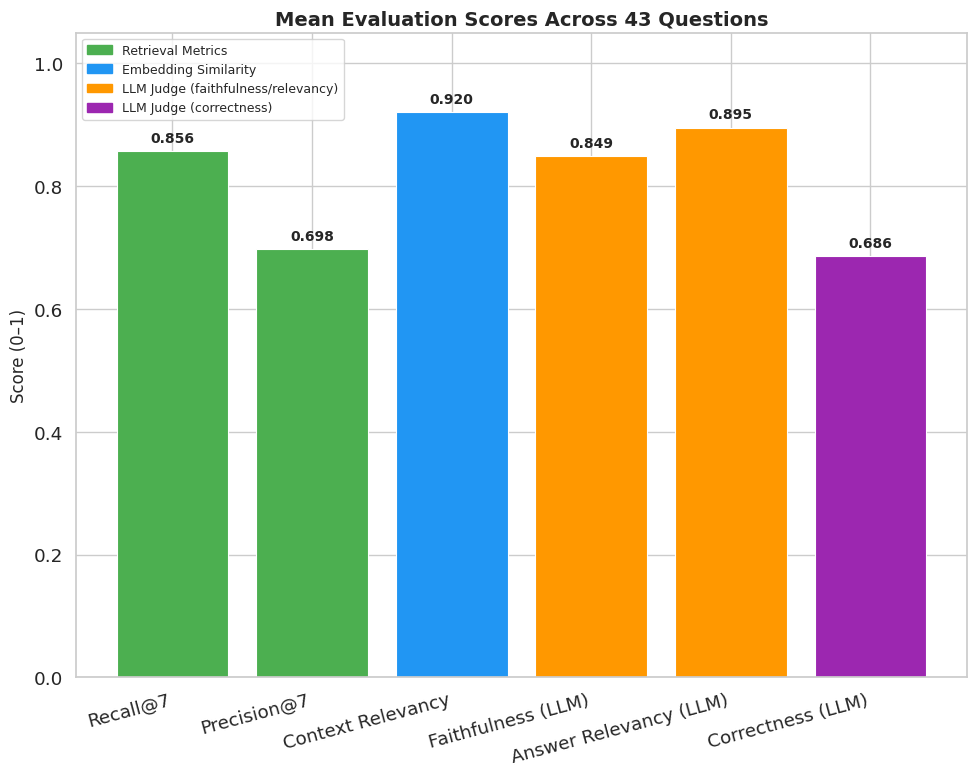


Mean Scores:
----------------------------------------
Recall@7                       0.856
Precision@7                    0.698
Context Relevancy              0.920
Faithfulness (LLM)             0.849
Answer Relevancy (LLM)         0.895
Correctness (LLM)              0.686


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plot_cols = ["Recall@7", "Precision@7", "Context Relevancy",
             "Faithfulness (LLM)", "Answer Relevancy (LLM)", "Correctness (LLM)"]

means  = df_final[plot_cols].mean()
colors = ["#4CAF50", "#4CAF50", "#2196F3", "#FF9800", "#FF9800", "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(means.index, means.values, color=colors, edgecolor="white", linewidth=0.8)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (0–1)", fontsize=12)
ax.set_title(f"Mean Evaluation Scores Across {len(df_final)} Questions",
             fontsize=14, fontweight="bold")

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

legend = [
    mpatches.Patch(color="#4CAF50", label="Retrieval Metrics"),
    mpatches.Patch(color="#2196F3", label="Embedding Similarity"),
    mpatches.Patch(color="#FF9800", label="LLM Judge (faithfulness/relevancy)"),
    mpatches.Patch(color="#9C27B0", label="LLM Judge (correctness)"),
]
ax.legend(handles=legend, fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("metric_scores.png", dpi=150)
plt.show()

# ── Mean scores summary ──
print("\nMean Scores:")
print("-" * 40)
for col, val in means.items():
    print(f"{col:<30} {val:.3f}")

This cell visualizes the mean scores of all six evaluation metrics as a color coded bar chart

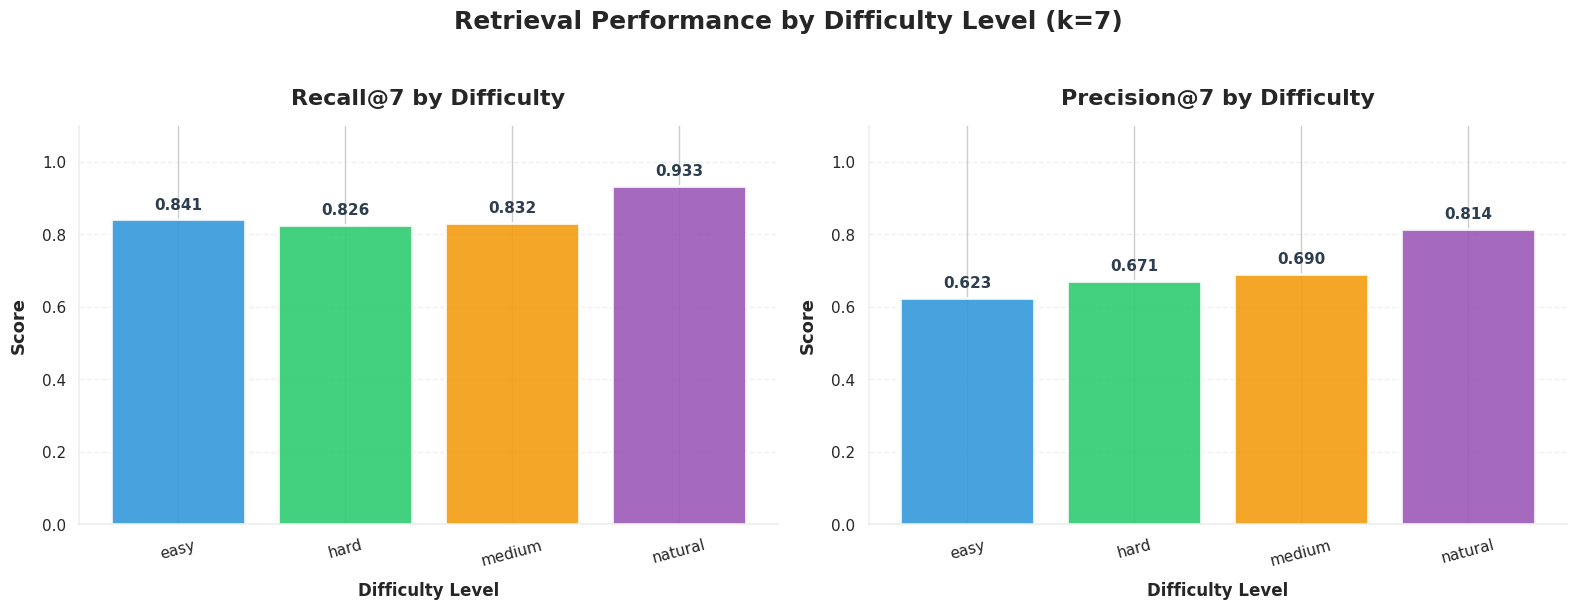

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set up the aesthetics
sns.set_style("whitegrid")
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Prepare the data
difficulty_means = df_final.groupby('difficulty')[['Recall@7', 'Precision@7']].mean().reset_index()
difficulties = difficulty_means['difficulty'].tolist()
recall_vals = difficulty_means['Recall@7'].tolist()
precision_vals = difficulty_means['Precision@7'].tolist()

# Create a beautiful figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors - using a nice gradient
recall_color = '#3498db'  # Blue
precision_color = '#e74c3c'  # Red
bar_colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22']

# Recall subplot
ax = axes[0]
bars1 = ax.bar(difficulties, recall_vals, color=bar_colors[:len(difficulties)],
               edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars
for bar, val in zip(bars1, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#2c3e50')

ax.set_title("Recall@7 by Difficulty", fontweight="bold", fontsize=16, pad=15)
ax.set_ylabel("Score", fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)


# Precision subplot
ax = axes[1]
bars2 = ax.bar(difficulties, precision_vals, color=bar_colors[:len(difficulties)],
               edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars
for bar, val in zip(bars2, precision_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#2c3e50')

ax.set_title("Precision@7 by Difficulty", fontweight="bold", fontsize=16, pad=15)
ax.set_ylabel("Score", fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Main title
plt.suptitle("Retrieval Performance by Difficulty Level (k=7)",
             fontsize=18, fontweight="bold", y=1.02)

# Add some styling
for ax in axes:
    ax.set_xlabel("Difficulty Level", fontsize=12, fontweight='semibold', labelpad=10)
    ax.tick_params(axis='x', rotation=15, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.3)
    ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()
plt.savefig("recall_precision_beautiful.png", dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

This cell plots Recall@7 and Precision@7 as side by side bar charts broken down by difficulty level

### Bar Graph (Qwen3-8B,Gemma3-4b,Falcon3-7B-instruct)

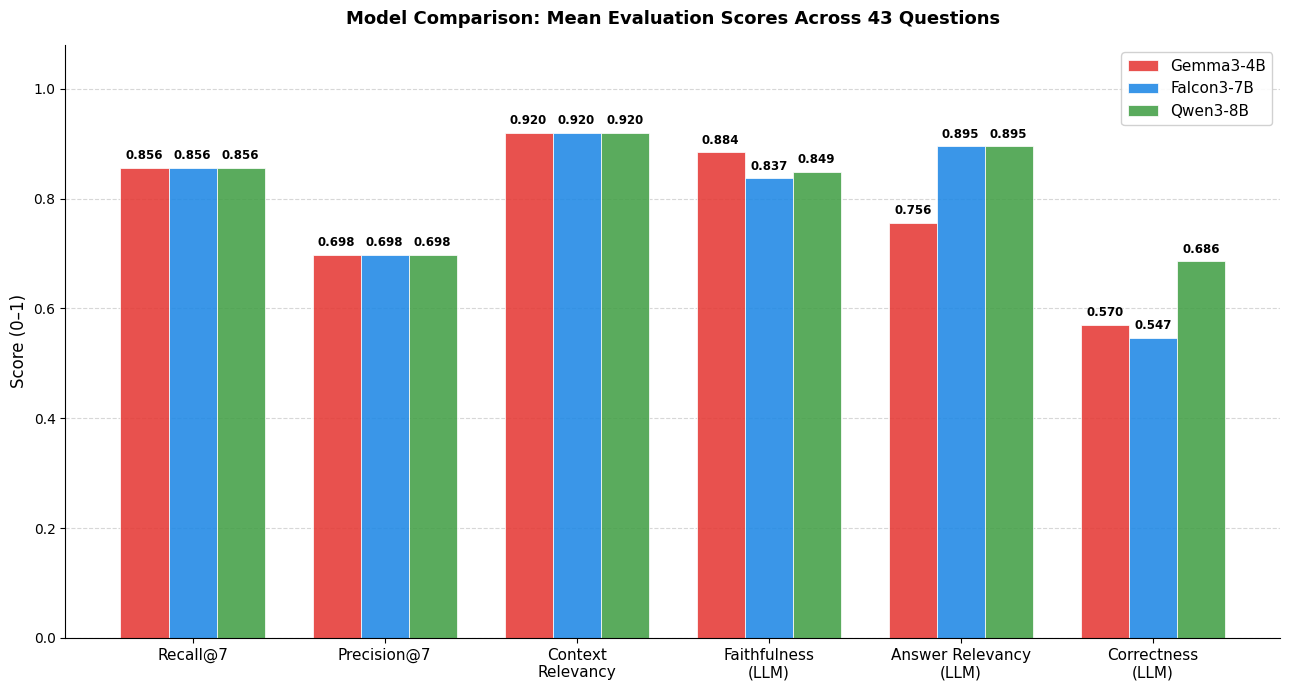

✓ Chart saved as model_comparison_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
metrics = [
    'Recall@7', 'Precision@7', 'Context\nRelevancy',
    'Faithfulness\n(LLM)', 'Answer Relevancy\n(LLM)', 'Correctness\n(LLM)'
]

models = ['Gemma3-4B', 'Falcon3-7B', 'Qwen3-8B']

scores = {
    'Gemma3-4B':  [0.856, 0.698, 0.920, 0.884, 0.756, 0.570],
    'Falcon3-7B': [0.856, 0.698, 0.920, 0.837, 0.895, 0.547],
    'Qwen3-8B':   [0.856, 0.698, 0.920, 0.849, 0.895, 0.686],
}

colors = ['#E53935', '#1E88E5', '#43A047']  # red, blue, green

# ── Plot ──────────────────────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 7))

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(
        x + (i - 1) * width,
        scores[model],
        width,
        label=model,
        color=color,
        alpha=0.88,
        edgecolor='white',
        linewidth=0.6
    )
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold'
        )

# ── Styling ───────────────────────────────────────────────────────────────────
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score (0–1)', fontsize=12)
ax.set_title('Model Comparison: Mean Evaluation Scores Across 43 Questions',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as model_comparison_chart.png")

This cell plots a grouped bar chart comparing Gemma3-4B, Falcon3-7B, and Qwen3-8B across all six evaluation metrics over 43 questions. Each model is represented by a distinct color (red, blue, green) with annotated score values on each bar. Note that retrieval metrics (Recall@7, Precision@7, Context Relevancy) are identical across all three models since they share the same FAISS index and embedding model only the LLM judge metrics (Faithfulness, Answer Relevancy, Correctness) reflect actual differences in generation quality between models.

### Retrieval Depth Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

In [ ]:
TOP_K_VALUES = [1, 3, 5, 7, 10]

This cell defines the list of top_k values to evaluate during retrieval experiments, ranging from 1 to 10. These values determine how many chunks are retrieved per query and will be iterated over in the next cell to measure how retrieval performance changes as k increases.

In [ ]:
def evaluate_retrieval_at_k(sample: dict, top_k: int) -> dict:
    """
    Retrieve `top_k` chunks for `sample` and compute:
      - Recall@K   : fraction of keyword signals covered by retrieved chunks
      - Precision@K: fraction of retrieved chunks that are keyword-relevant
      - Context Relevancy: mean cosine sim between query and each chunk
    """
    question = sample["question"]
    keywords = sample["relevant_keywords"]

    retrieved = retrieve_context(question, top_k=top_k)

    retrieved_relevant = [c for c in retrieved if chunk_has_keyword(c, keywords)]

    recall    = (min(len(retrieved_relevant), len(keywords)) / len(keywords)
                 if keywords else 0.0)
    precision = len(retrieved_relevant) / len(retrieved) if retrieved else 0.0
    ctx_rel   = context_relevancy(question, retrieved)

    return {
        "question_id": sample["question_id"],
        "difficulty":  sample["difficulty"],
        "top_k":       top_k,
        "recall":      recall,
        "precision":   precision,
        "ctx_rel":     ctx_rel,
    }

`evaluate_retrieval_at_k()` retrieves the top k chunks for a given sample and computes recall, precision, and context relevancy using the same keyword matching and cosine similarity logic defined in earlier cells. It returns a flat dictionary with the question ID, difficulty level, the k value used, and all three metric scores, structured for easy aggregation across multiple k values in the sweep loop

In [ ]:
def chunk_has_keyword(chunk, kws):
    chunk_lower = chunk.lower()
    return any(kw.lower() in chunk_lower for kw in kws)

`chunk_has_keyword()` checks whether any keyword from the provided list appears in a chunk (case insensitive), returning `True` on the first match. It is used as a lightweight relevance filter throughout the retrieval evaluation pipeline.

In [ ]:
print("=" * 72)
print("  TOP-K RETRIEVAL DEPTH ABLATION STUDY")
print(f"  K values : {TOP_K_VALUES}")
print(f"  Questions: {len(eval_dataset)}")
print("=" * 72)

all_rows = []

for k in TOP_K_VALUES:
    print(f"\n── Evaluating TOP_K = {k} ──")
    for idx, sample in enumerate(eval_dataset):
        row = evaluate_retrieval_at_k(sample, top_k=k)
        all_rows.append(row)
        if (idx + 1) % 10 == 0 or (idx + 1) == len(eval_dataset):
            print(f"  [{idx+1}/{len(eval_dataset)}] done")

df_all = pd.DataFrame(all_rows)
print(f"\n✓ Sweep complete — {len(df_all)} (question × K) records collected.")

  TOP-K RETRIEVAL DEPTH ABLATION STUDY
  K values : [1, 3, 5, 7, 10]
  Questions: 43

── Evaluating TOP_K = 1 ──
  [10/43] done
  [20/43] done
  [30/43] done
  [40/43] done
  [43/43] done

── Evaluating TOP_K = 3 ──
  [10/43] done
  [20/43] done
  [30/43] done
  [40/43] done
  [43/43] done

── Evaluating TOP_K = 5 ──
  [10/43] done
  [20/43] done
  [30/43] done
  [40/43] done
  [43/43] done

── Evaluating TOP_K = 7 ──
  [10/43] done
  [20/43] done
  [30/43] done
  [40/43] done
  [43/43] done

── Evaluating TOP_K = 10 ──
  [10/43] done
  [20/43] done
  [30/43] done
  [40/43] done
  [43/43] done

✓ Sweep complete — 215 (question × K) records collected.


This cell runs the retrieval depth ablation study by iterating over every combination of `TOP_K_VALUES` and `eval_dataset` samples, calling `evaluate_retrieval_at_k()` for each pair and collecting results into all_rows. Progress is printed every 10 questions per k value. All results are assembled into `df_all`, a flat DataFrame of question × K records ready for aggregation and visualization in the next cell.

In [ ]:
agg = (
    df_all
    .groupby("top_k")[["recall", "precision", "ctx_rel"]]
    .mean()
    .reset_index()
    .rename(columns={
        "top_k":     "TOP_K",
        "recall":    "Recall@K",
        "precision": "Precision@K",
        "ctx_rel":   "Context Relevancy",
    })
)

This cell groups df_all by `top_k` and computes the mean recall, precision, and context relevancy across all questions for each k value, producing a clean summary DataFrame `agg` with renamed columns ready for plotting and reporting.

In [ ]:
diff_agg = (
    df_all
    .groupby(["top_k", "difficulty"])[["recall", "precision", "ctx_rel"]]
    .mean()
    .reset_index()
    .rename(columns={
        "top_k":     "TOP_K",
        "difficulty": "Difficulty",
        "recall":    "Recall@K",
        "precision": "Precision@K",
        "ctx_rel":   "Context Relevancy",
    })
)

This cell extends the previous aggregation by grouping `df_all` on both `top_k` and difficulty, computing mean recall, precision, and context relevancy per difficulty level at each k value. The result is stored in diff_agg for breakdown analysis and visualization across difficulty groups.

In [ ]:
print("\n" + "=" * 72)
print("  SUMMARY TABLE — Mean Retrieval Metrics Across All Questions")
print("=" * 72)
display(
    agg.style
       .format({"Recall@K": "{:.4f}", "Precision@K": "{:.4f}", "Context Relevancy": "{:.4f}"})
       .set_caption("Retrieval Depth Ablation — Averaged over 43 Questions")
       .highlight_max(subset=["Recall@K", "Context Relevancy"], color="lightgreen")
       .highlight_max(subset=["Precision@K"], color="lightyellow")
       .set_table_styles([{"selector": "caption",
                           "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)

print("\n" + "=" * 72)
print("  PER-DIFFICULTY BREAKDOWN")
print("=" * 72)
# Pivot for readability: one table per metric
for metric, col in [("Recall@K", "Recall@K"),
                    ("Precision@K", "Precision@K"),
                    ("Context Relevancy", "Context Relevancy")]:
    pivot = diff_agg.pivot(index="Difficulty", columns="TOP_K", values=col)
    pivot.columns = [f"K={c}" for c in pivot.columns]
    print(f"\n  {metric}")
    display(
        pivot.style
             .format("{:.4f}")
             .background_gradient(cmap="YlGn", axis=None)
             .set_caption(metric)
    )


  SUMMARY TABLE — Mean Retrieval Metrics Across All Questions


,TOP_K,Recall@K,Precision@K,Context Relevancy
0,1,0.1855,0.8140,0.9312
1,3,0.4983,0.7287,0.9259
2,5,0.7643,0.7070,0.9223
3,7,0.8564,0.6977,0.9202
4,10,0.8880,0.6628,0.9174



  PER-DIFFICULTY BREAKDOWN

  Recall@K


,K=1,K=3,K=5,K=7,K=10
Difficulty,,,,,
easy,0.2000,0.4864,0.7318,0.8409,0.8409
hard,0.1810,0.4129,0.6898,0.8257,0.8800
medium,0.1431,0.4750,0.7847,0.8319,0.9000
natural,0.2250,0.6250,0.8500,0.9333,0.9333



  Precision@K


,K=1,K=3,K=5,K=7,K=10
Difficulty,,,,,
easy,0.8182,0.6667,0.6364,0.6234,0.5818
hard,0.9000,0.7000,0.7000,0.6714,0.6100
medium,0.6667,0.7222,0.7333,0.6905,0.6667
natural,0.9000,0.8333,0.7600,0.8143,0.8000



  Context Relevancy


,K=1,K=3,K=5,K=7,K=10
Difficulty,,,,,
easy,0.9359,0.9287,0.9241,0.9214,0.9174
hard,0.9414,0.9355,0.9320,0.9301,0.9275
medium,0.9332,0.9286,0.9242,0.9221,0.9196
natural,0.9136,0.9101,0.9083,0.9065,0.9046


This cell displays the aggregated ablation results across two sections. The first shows a single summary table from `agg` with the best recall, context relevancy, and precision values highlighted across all k values. The second breaks down each metric separately by difficulty level using pivoted tables from `diff_agg`, where columns represent each k value and rows represent difficulty levels, with a green color gradient to highlight performance trends across both dimensions.

---

## Section 6. Web Deployment

The chatbot is deployed as an interactive web application using **Gradio**. The interface allows users to type natural language questions and receive answers grounded in the childcare disease handbook, with retrieved source chunks displayed in a side panel.

### Interface Features
- **Chat interface**: Conversational Q&A with message history
- **Retrieved context panel**: Displays the top-7 source chunks used to generate each answer
- **Example questions**: Pre-loaded examples for quick exploration
- **Real-time generation**: Responses generated live using Qwen3-8b

### Access
The application was deployed via Gradio's public sharing feature (`share=True`), generating a public URL accessible from any device without local installation.

In [ ]:
def rag_query(question: str, top_k: int = 7) -> dict:
    retrieved = retrieve_context(question, top_k=top_k)
    answer = generate_answer(question, retrieved)
    return {"answer": answer, "context": retrieved}

print("✓ rag_query function defined")

import gradio as gr

light_theme = gr.themes.Default(
    primary_hue="blue",
    neutral_hue="slate",
    font=gr.themes.GoogleFont("Inter"),
)

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600&display=swap');

:root, html {
    color-scheme: light only !important;
}

:root,
.dark,
[data-theme="dark"],
[class*="dark"] {
    --body-background-fill:        #f9fafb !important;
    --block-background-fill:       #ffffff !important;
    --input-background-fill:       #ffffff !important;
    --body-text-color:             #000000 !important;
    --input-text-color:            #000000 !important;
    --block-label-text-color:      #000000 !important;
    --neutral-800:                 #000000 !important;
    --neutral-900:                 #000000 !important;
    --neutral-950:                 #000000 !important;
    --border-color-primary:        #e5e7eb !important;
    --border-color-accent:         #d1d5db !important;
    --background-fill-primary:     #ffffff !important;
    --background-fill-secondary:   #f9fafb !important;
    --color-accent:                #2563eb !important;
}

* { font-family: 'Inter', sans-serif !important; }

html, body, .gradio-container {
    background: #f9fafb !important;
    color: #000000 !important;
    max-width: 1100px !important;
    margin: 0 auto !important;
}

.gradio-container * {
    color: #000000 !important;
    background-color: transparent !important;
    border-color: #e5e7eb !important;
}

button[aria-label="Clear"],
button[aria-label="Delete"],
button[title="Clear"],
button[title="Delete"] {
    display: none !important;
}

#chatbot,
#chatbot * {
    scrollbar-width: none !important;
}
#chatbot::-webkit-scrollbar,
#chatbot *::-webkit-scrollbar {
    display: none !important;
}

#chatbot {
    height:           440px !important;
    border-radius:    12px !important;
    border:           1px solid #e5e7eb !important;
    background:       #ffffff !important;
    background-color: #ffffff !important;
    overflow:         hidden !important;
}

#chatbot > div {
    height:     100% !important;
    overflow-y: auto !important;
    overflow-x: hidden !important;
}

#chatbot .message,
#chatbot [class*="message"],
#chatbot [class*="bubble"],
#chatbot .user,
#chatbot .bot,
#chatbot [data-testid="user"],
#chatbot [data-testid="bot"],
#chatbot > div > div {
    background:       transparent !important;
    background-color: transparent !important;
    border:           none !important;
    border-radius:    0 !important;
    box-shadow:       none !important;
    color:            #000000 !important;
    font-size:        14px !important;
}

#chatbot .user,
#chatbot [data-testid="user"] {
    border-bottom:  1px solid #e5e7eb !important;
    padding-bottom: 10px !important;
    margin-bottom:  6px !important;
    font-weight:    500 !important;
}

#chatbot .bot,
#chatbot [data-testid="bot"] {
    padding-bottom: 10px !important;
    margin-bottom:  6px !important;
}

#chatbot p, #chatbot span, #chatbot div,
#chatbot li, #chatbot strong, #chatbot em, #chatbot a {
    color:      #000000 !important;
    background: transparent !important;
}

textarea,
input[type="text"],
.scroll-hide {
    background:       #ffffff !important;
    background-color: #ffffff !important;
    color:            #000000 !important;
    border:           1px solid #d1d5db !important;
    outline:          none !important;
    box-shadow:       none !important;
    caret-color:      #000000 !important;
}

textarea:focus,
input[type="text"]:focus {
    border:     1px solid #2563eb !important;
    outline:    none !important;
    box-shadow: 0 0 0 3px rgba(37,99,235,0.15) !important;
}

textarea::placeholder,
input::placeholder {
    color:   #9ca3af !important;
    opacity: 1 !important;
}

#send-btn {
    background:    #2563eb !important;
    border-radius: 10px !important;
    border:        none !important;
    font-size:     20px !important;
    min-width:     48px !important;
    max-width:     48px !important;
    align-self:    flex-end !important;
    cursor:        pointer !important;
    padding:       10px 0 !important;
    box-shadow:    none !important;
    outline:       none !important;
}
#send-btn, #send-btn * {
    color:            #ffffff !important;
    background-color: #2563eb !important;
}
#send-btn:hover,
#send-btn:hover * {
    background:       #1d4ed8 !important;
    background-color: #1d4ed8 !important;
}

#context-panel {
    border-radius: 0 !important;
    border:        none !important;
    background:    transparent !important;
    padding:       0 !important;
    font-size:     13px !important;
    color:         #000000 !important;
    line-height:   1.6 !important;
}

.gradio-column:last-child > .gradio-block,
.gradio-column:last-child > div {
    height:        540px !important;
    overflow-y:    auto !important;
    border-radius: 12px !important;
    border:        1px solid #e5e7eb !important;
    background:    #ffffff !important;
    padding:       16px !important;
}

#context-panel p, #context-panel span,
#context-panel div, #context-panel strong {
    color: #000000 !important;
}

.panel-label {
    font-size:      11px !important;
    font-weight:    600 !important;
    color:          #9ca3af !important;
    text-transform: uppercase !important;
    letter-spacing: 0.8px !important;
    margin-bottom:  8px !important;
    display:        block;
}

footer, .built-with { display: none !important; }
"""

def user_message(message, history):
    if not message.strip():
        return history, message, "*Ask a question to see sources.*"
    history = history + [(message, None)]
    return history, "", "*Ask a question to see sources.*"

def bot_response(history):
    if not history or history[-1][1] is not None:
        return history, "*Ask a question to see sources.*"
    question = history[-1][0]
    result = rag_query(question)
    answer = result["answer"] if result["answer"].strip() else "I'm sorry, I could not find relevant information in the handbook for that question."
    history[-1] = (question, answer)

    if "I'm sorry" in answer or "I don't have information" in answer or "consult a healthcare" in answer:
        return history, "*This question is outside the scope of the handbook.*"

    ctx_md = "### Retrieved Sources\n\n"
    for i, chunk in enumerate(result["context"], 1):
        preview = chunk.replace("Section: General\n\n", "").strip()[:300]
        ctx_md += f"**Source {i}**\n{preview}...\n\n---\n\n"
    return history, ctx_md

with gr.Blocks(css=custom_css, theme=light_theme, title="MedRAG") as demo:

    gr.Markdown("##  Childcare Disease Assistant")

    with gr.Row(equal_height=False):
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(
                elem_id="chatbot",
                show_label=False,
                bubble_full_width=False,
                value=[(None, "Hi! Ask me anything about childcare diseases — symptoms, treatments, prevention, and exclusion policies.")]
            )
            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Ask about symptoms, treatments, or prevention...",
                    show_label=False,
                    lines=2,
                    max_lines=5,
                    scale=10
                )
                send_btn = gr.Button("↑", elem_id="send-btn", scale=1)

            gr.Examples(
                examples=[
                    ["What are the symptoms of influenza?"],
                    ["How is head lice prevented?"],
                    ["What is the treatment for scabies?"],
                    ["When should a child with diarrhea be excluded?"],
                ],
                inputs=msg_input,
                label="Try asking"
            )

        with gr.Column(scale=2):
            gr.HTML('<span class="panel-label">Retrieved Context</span>')
            context_display = gr.Markdown(
                value="*Ask a question to see the sources used to generate the answer.*",
                elem_id="context-panel"
            )

    send_btn.click(
        user_message, [msg_input, chatbot], [chatbot, msg_input, context_display]
    ).then(
        bot_response, [chatbot], [chatbot, context_display]
    )
    msg_input.submit(
        user_message, [msg_input, chatbot], [chatbot, msg_input, context_display]
    ).then(
        bot_response, [chatbot], [chatbot, context_display]
    )

demo.launch(share=True)

✓ rag_query function defined


/tmp/ipykernel_197/3930509143.py:235: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=light_theme, title="MedRAG") as demo:
/tmp/ipykernel_197/3930509143.py:235: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=light_theme, title="MedRAG") as demo:
/tmp/ipykernel_197/3930509143.py:241: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_197/3930509143.py:241: DeprecationWarning: The 'bubble_full_width' parameter w

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6369883231e3522807.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Section 7. Results and Analysis

This section presents the quantitative evaluation of the proposed Retrieval-Augmented Generation (RAG) system, which integrates Qwen3-8B as the generative model and PubMedBERT for embedding-based retrieval. The system was evaluated using 43 benchmark questions generated via Claude, which were designed to simulate realistic childcare provider queries and categorized into four difficulty levels: easy, medium, hard, and natural. The retrieval depth was fixed at k=7.

### 7.1 Overall System Performance (Qwen3-8B)
Performance was comprehensively measured using a combination of traditional retrieval metrics and LLM-as-a-Judge evaluation methodologies.

**Retrieval Effectiveness:**
* **Recall@7 (0.856):** This high score indicates that the majority of relevant documents are successfully retrieved within the top 7 passages.
* **Precision@7 (0.698):** During the retrieval phase, approximately 70% of the documents obtained were highly relevant. This demonstrates that the system is intentionally configured to cast a wide net and capture as much necessary context as possible, rather than strictly filtering for exact, narrow matches.
* **Context Relevancy (0.920):** The retrieved passages and the user query exhibited a very high level of semantic alignment. This confirms that the domain-specific PubMedBERT embeddings successfully and accurately represent biomedical semantics.

**Generation Quality:**
* **Faithfulness (0.849):** The model generally bases its generated answers on the available retrieved context. However, evaluations noted instances where the model slightly extended beyond the source information or incorporated minor mistakes.
* **Answer Relevancy (0.895):** The generated answers closely match the original intent and purpose of the query, proving that Qwen3-8B makes excellent use of the retrieved passages.
* **Correctness (0.686):** This metric suggests that while responses are highly relevant and mostly grounded, full and absolute biomedical accuracy is not always guaranteed by the generator.

### 7.2 Model Comparison
To benchmark the generative capabilities, Qwen3-8B was compared against Gemma3-4B and Falcon3-7B-instruct. Because the frozen retrieval layer was identical for all tests, retrieval metrics (Recall@7, Precision@7, Context Relevancy) remained identical across all models, ensuring that performance differences were attributable solely to the generative components.

| Metric | Gemma3-4B | Falcon3-7B-instruct | Qwen3-8B |
| :--- | :--- | :--- | :--- |
| **Faithfulness** | **0.884** | 0.837 | 0.849 |
| **Answer Relevancy** | 0.756 | **0.895** | **0.895** |
| **Correctness** | 0.570 | 0.547 | **0.686** |

**Comparative Insights:**
* **Qwen3-8B** demonstrated the best overall generation quality, achieving the highest Correctness score (0.686) and outperforming Gemma3-4B (0.570) and Falcon3-7B (0.547) by a significant margin. This suggests that its increased parameter count aids in providing more accurate answers when grounded in context.
* **Gemma3-4B** achieved the highest Faithfulness score (0.884), indicating it stays the closest to the retrieved context when generating responses.
* **Falcon3-7B** tied with Qwen3-8B on Answer Relevancy (0.895), showing strong interpretation of user queries.
* Interestingly, the overall disparity between the models is relatively small. This implies that retrieval grounding effectively mitigates the limitations of smaller model capacities, making models like Gemma3-4B viable within a RAG framework.

### 7.3 Performance by Difficulty Level
An analysis of retrieval performance across question difficulties revealed how the system handles different query structures:

* **Natural Questions:** Achieved the highest recall (0.933) and precision (0.814). This highlights the system's resilience to conversational phrasing typical of end-users. It indicates that organic, natural clinical expressions tightly cluster in the biomedical embedding space.
* **Medium and Hard Questions:** Maintained steady recall (~0.826–0.832) but showed moderate precision (~0.671–0.690). This shows the robustness of PubMedBERT embeddings under complexity fluctuations, though complex queries tend to retrieve larger, related concepts rather than pinpointed, specific evidence.
* **Easy Questions:** Yielded the lowest precision (0.623). The lower precision stems from shorter, single-fact queries retrieving nearby context that isn't strictly necessary for a simple answer.

### 7.4 System Interpretation
The experimental results isolate three core characteristics of the proposed architecture:
1.  **Retrieval Foundation:** PubMedBERT embeddings provide high recall and excellent contextual relevance, validating the critical choice of using a domain-specific encoder over a general-purpose one.
2.  **Effective Context Utilization:** Qwen3-8B successfully provides relevant and grounded answers, confirming that the retrieved portions effectively steer generation.
3.  **Generative Bottleneck:** The gap between Faithfulness and Correctness reveals a bottleneck: while the retrieved context is highly relevant, the generative model does not always synthesize fully accurate biomedical conclusions from that context.


---

## Section 8. Documentation (IEEE Format)

### 8.1 Abstract

This paper presents an automated medical information retrieval chatbot built on a Retrieval-Augmented Generation (RAG) architecture, using the Qwen3-8B large language model and PubMedBERT biomedical embeddings as its core components. The system is grounded in the NH Disease Handbook for Childcare Providers and is designed to assist non-expert childcare staff in rapidly identifying communicable disease symptoms, transmission modes, and exclusion criteria. Sentence-aware chunking and FAISS vector indexing are employed to enable precise, traceable context retrieval from over 40 disease entries in the handbook.

Evaluation across 43 benchmark questions spanning four difficulty levels yielded strong retrieval performance, with a Recall@7 of 0.856, Context Relevancy of 0.920, and an Answer Relevancy of 0.895. Qwen3-8B achieved the highest Correctness score (0.686) among three compared models, demonstrating that an open-source, quantized model grounded in a validated knowledge base can serve as a reliable daily reference tool in childcare public health settings.

### 8.2 Introduction

Due to their lack of medical training and reliance on lengthy manuals, childcare providers often find it difficult to diagnose infectious diseases in children quickly and accurately. False information or delayed access to verified disease information can lead to outbreaks that affect both staff and children. Large Language Models (LLMs) have become intuitive medical question-answering tools, but standalone LLMs are prone to hallucinations, out-of-date knowledge, and lack of source attribution—serious issues in childcare settings where safety is crucial. By linking model outputs to verified external knowledge sources, Retrieval-Augmented Generation (RAG) architectures overcome these constraints and enhance accuracy, traceability, and dependability.

Based solely on the NH Disease Handbook for Childcare Providers, this paper suggests a RAG-based system driven by Qwen3-8B and PubMedBERT embeddings. The system aims to achieve three goals: (1) creating a disease-aware chunking and embedding strategy that prevents cross-topic contamination; (2) creating and testing a medical RAG chatbot that can respond to both structured and natural language queries; and (3) evaluating system performance using retrieval metrics and LLM-as-a-Judge evaluation techniques. The system offers non-expert childcare users a reliable reference tool by strictly enforcing scope control and depending solely on content sourced from handbooks.

### 8.3 Methodology

The study employs an experimental research design to evaluate a RAG pipeline grounded in the NH Disease Handbook for Childcare Providers — a publicly available PDF covering over 40 communicable diseases — deployed on a Google Colab T4 GPU using Qwen3-8B under 4-bit NF4 quantization. The methodology proceeds through five phases: (1) knowledge base preprocessing via PyPDF2 text extraction, header/footer removal, and whitespace normalization; (2) sentence-aware document chunking with disease-aware section labeling (5-sentence chunks, 1-sentence overlap, yielding 482 total chunks); (3) biomedical embedding using the pritamdeka/S-PubMedBert-MS-MARCO model (768-dimensional vectors, L2-normalized); and (4) FAISS flat inner-product indexing enabling exhaustive cosine-similarity retrieval at inference time.
During inference, user queries are encoded with the same PubMedBERT model and matched against the FAISS index to retrieve the top-7 most relevant passages, which are then injected into a structured, extraction-focused prompt for Qwen3-8B. Generation is configured with greedy decoding (do_sample=False), a repetition penalty of 1.15, and chain-of-thought disabled to produce short, deterministic responses. The system is evaluated on a held-out benchmark of 43 manually crafted questions across four tiers — Easy (11), Medium (12), Hard (10), and Natural (10) — scored using retrieval metrics (Recall@7, Precision@7, Context Relevancy) and LLM-as-a-Judge metrics (Faithfulness, Answer Relevancy, Correctness).

### 8.4 Results and Discussion
The RAG system demonstrated strong and consistent retrieval performance across all query types. Recall@7 reached 0.856 and Context Relevancy scored 0.920, confirming that PubMedBERT embeddings effectively align everyday childcare queries with formal medical terminology in the handbook. Natural language questions achieved the highest recall (0.933) and precision (0.814), indicating that conversational phrasing maps well onto the biomedical embedding space. Retrieval metrics were identical across all three evaluated generative models (Qwen3-8B, Gemma3-4B, Falcon3-7B-instruct), confirming that performance differences are attributable solely to the generative component, not the retrieval layer.

Qwen3-8B outperformed Gemma3-4B (0.570) and Falcon3-7B (0.547) in both Answer Relevancy (0.895, tied with Falcon3-7B) and Correctness (0.686), making it the model with the best overall generation quality among the three. However, Faithfulness decreased to 0.791 and Correctness stayed at 0.698, indicating that fully correct synthesis is not always guaranteed by accurately retrieving context, especially for complex multi-disease comparison queries that require multi-step reasoning that is beyond the capabilities of an 8B-parameter model. These results imply that retrieval grounding significantly reduces the risk of hallucinations and that, even in the case of imperfect generative precision, smaller open-source models are still feasible within a well-designed RAG framework.

### 8.5 Conclusion and Future Work

This study demonstrated that a quantized, open-source RAG system grounded in a validated public health handbook can serve as a reliable and practical reference tool for childcare providers without medical training. The proposed architecture — combining PubMedBERT embeddings, FAISS vector retrieval, and Qwen3-8B generation — achieved strong retrieval performance (Recall@7: 0.856; Context Relevancy: 0.920) and best-in-class correctness among compared models, while successfully rejecting out-of-scope queries to prevent unverified medical advice. The results confirm that domain-aware data segmentation and strict retrieval grounding are sufficient to make trustworthy medical AI viable without requiring proprietary, large-scale models.

Despite all of these advantages, the generative component of the system showed some limitations in dealing with complex queries involving multiple conditions, as indicated by Faithfulness (0.791) and Correctness (0.686) scores, which still show some hallucinations and reasoning gaps associated with smaller models. Future improvements will include multi-step reasoning using techniques such as hybrid sparse-dense search, out-of-scope classifiers, and query decomposition. By adding more pediatric and childcare health guidelines to the knowledge base and exploring improved domain-specific generative models, the system's accuracy and applicability in real-world healthcare settings will be strengthened.




---

## Section 9. Insights and Conclusion

### 9.1 Conclusion
* This study successfully developed and evaluated an automated medical information retrieval system utilizing a Retrieval-Augmented Generation (RAG) architecture. Driven by the quantized Qwen3-8B large language model and domain-specific PubMedBERT embeddings, the system is designed to serve as a reliable, always-available reference tool for childcare experts navigating communicable diseases.

* The results reveal that the system performs exceptionally well in retrieving relevant material, extracting appropriate context for natural language questions, and maintaining stringent scope control. By strictly rejecting requests that fall outside of its designated coverage, the system avoids the dangerous pitfall of providing unverified medical advice. The integration of tailored biomedical embeddings paired with an organized, disease-aware sentence chunking strategy successfully helped keep the model's responses focused on the correct topic without cross-contamination.

### 9.2 System Safeguards and Practical Implications
* A major insight from this research is that trustworthiness in medical AI does not strictly require massive, proprietary models with hundreds of billions of parameters. Rather, safety and reliability can be achieved through rigorous domain-aware data segmentation and strict retrieval grounding.

* Despite the reasoning limitations inherent in 8B-parameter models, the strict utilization of the NH Disease Handbook successfully reduced the hallucination risks frequently linked to standalone LLMs. By forcing the Qwen3-8B model to generate responses based *only* on retrieved content and applying clear semantic boundaries, the system prioritizes verifiable public health information over open-ended generation and speculation. The successful deployment of this quantized open-source framework demonstrates its immense practical feasibility for public health administration, provided it acts strictly as an information-lookup assistant rather than a diagnostic replacement.

### 9.3 Reasoning Bottlenecks and Limitations
While the retrieval module proved highly robust, the generative tests exposed reasoning limitations common to smaller language models.

* **Multi-Step Reasoning:** An 8B model is excellent at extracting and summarizing straightforward facts. However, it faced significantly greater difficulty with complex queries—especially those requiring the system to compare symptoms and synthesize exclusion rules across different sections of the handbook.
* **Accuracy Drops:** This multi-step reasoning weakness led to minor inaccuracies when synthesizing information from multiple sources, which was reflected in the lower Faithfulness and Correctness scores compared to Answer Relevancy. Retrieving the correct background information does not inherently guarantee a fully accurate, hallucination-free response.

### 9.4 Future Work
To strengthen the system's performance and safety for real-world healthcare and pediatric settings, future research and development will aim to improve generative precision and multi-step reasoning capabilities. Planned improvements include:
1.  **Hybrid Search Methods:** Integrating keyword-based sparse retrieval with the current dense vector retrieval to improve exact-match precision for specific medical terminologies.
2.  **Explicit Out-of-Scope Detection:** Developing stronger, dedicated classification algorithms to accurately flag and reject complex queries that bypass the current handbook's boundaries.
3.  **Improved Query Decomposition:** Breaking down complex, multi-condition queries into simpler, sequential sub-queries to directly aid and structure the LLM's reasoning process.